# Predicting IoT Network Flow Duration on RT-IoT2022
### MSc Cybersecurity — CMP7239 Applied Machine Learning
**Santhakumar Parivallal** (25156775) · Birmingham City University · 2025–2026  
*Module Leader: Dr Mohamed Ihmeida*

---

**Study design overview:**

| Step | Description |
|------|-------------|
| Full dataset | 117,915 deduplicated flows — **no sub-sampling** |
| Preprocessing | Dedup → label-encode → log1p target → StandardScaler |
| Baseline | All features surviving preprocessing (50 → 39 after sanity filters) |
| FS Stage 1 | Low-variance removal + correlation pruning (`|r|>0.95`) |
| FS Stage 2 | Best ranking method identified via 3-method comparison |
| FS Stage 3 | K-sweep → 3 progressive reduction levels (Mild / Moderate / Optimal) |
| Models | 4 classical ML + 2 DL trained on **4 feature sets × 6 models = 24 runs** |
| Output | Figures (200 dpi PNG) + saved models packed into a downloadable ZIP |

## 1 · Imports & Global Settings

In [1]:
# ── Standard library ──────────────────────────────────────────────
import os, sys, time, random, warnings, zipfile
warnings.filterwarnings("ignore")

# ── Numerics ──────────────────────────────────────────────────────
import numpy  as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot   as plt
import matplotlib.gridspec as gridspec
import seaborn             as sns

# ── figure defaults ───────────────────────────
matplotlib.rcParams.update({
    "figure.dpi"         : 150,
    "savefig.dpi"        : 200,
    "font.family"        : "DejaVu Sans",
    "font.size"          : 11,
    "axes.titlesize"     : 13,
    "axes.labelsize"     : 11,
    "xtick.labelsize"    : 10,
    "ytick.labelsize"    : 10,
    "legend.fontsize"    : 10,
    "figure.titlesize"   : 14,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "axes.grid"          : True,
    "grid.alpha"         : 0.25,
    "figure.constrained_layout.use": True,
})
PALETTE = ["#2E86AB","#E84855","#3BB273","#F5A623","#9B59B6","#1ABC9C"]
sns.set_palette(PALETTE)

# ── Sklearn ───────────────────────────────────────────────────────
from sklearn.preprocessing       import StandardScaler, LabelEncoder
from sklearn.model_selection      import train_test_split
from sklearn.feature_selection    import mutual_info_regression
from sklearn.metrics              import (mean_absolute_error, mean_squared_error,
                                          r2_score, explained_variance_score)
from sklearn.ensemble             import (GradientBoostingRegressor,
                                          ExtraTreesRegressor, AdaBoostRegressor)
from sklearn.linear_model         import HuberRegressor
import joblib

# ── TensorFlow / Keras ───────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Seeds ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# ── Directories ───────────────────────────────────────────────────
os.makedirs("saved_models", exist_ok=True)
os.makedirs("figures",      exist_ok=True)

def savefig(name):
    """Save current figure and close."""
    plt.savefig(f"figures/{name}.png", bbox_inches="tight")
    plt.show()

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {bool(tf.config.list_physical_devices('GPU'))}")
print("Environment ready ✓")

TensorFlow : 2.19.0
GPU        : True
Environment ready ✓


## 2 · Load Dataset

In [2]:
# ── Upload the CSV in Colab: Files → Upload, then set path below ──
CSV_PATH = "rt_iot2022_regression_ready_50_features.csv"

df_raw = pd.read_csv(CSV_PATH)
TARGET = "flow_duration"
print(f"Shape   : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Target  : {TARGET}")
print(f"Missing : {df_raw.isna().sum().sum()}")
df_raw.head(3)

Shape   : 123,117 rows × 51 columns
Target  : flow_duration
Missing : 0


,id.orig_p,id.resp_p,proto,service,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,...,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,flow_duration
0,38667,1883,tcp,mqtt,9,5,3,3,0.281148,0.156193,...,7.714286,11.618477,761.985779,29729182.96,32011597.87,4001449.734,10403073.63,4438.877106,1511693.954,32.011598
1,51143,1883,tcp,mqtt,9,5,3,3,0.282277,0.156821,...,7.714286,11.618477,247.001648,29855277.06,31883584.02,3985448.003,10463455.56,4214.048386,1576435.804,31.883584
2,44761,1883,tcp,mqtt,9,5,3,3,0.280164,0.155647,...,7.428571,11.229866,283.956528,29842149.02,32124053.00,4015506.625,10442377.92,2456.903458,1476048.946,32.124053


## 3 · Exploratory Data Analysis

Comprehensive EDA before any modelling decisions are made.

### 3.1 · Data Quality Overview

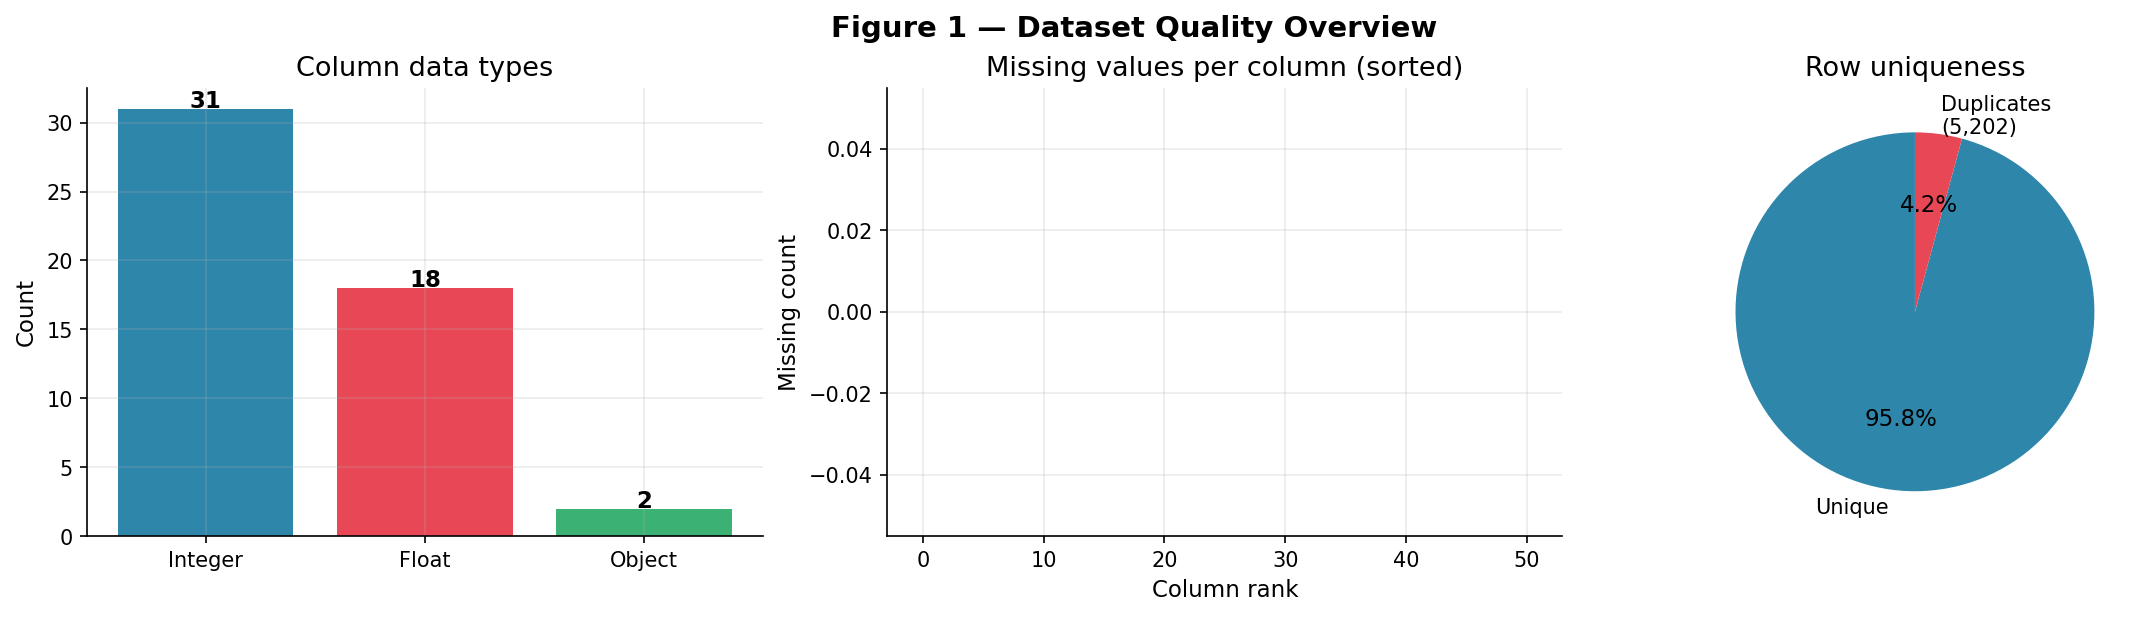

Total duplicate rows : 5,202
Total missing values : 0


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Figure 1 — Dataset Quality Overview", fontweight="bold")

# dtype breakdown
dtype_counts = df_raw.dtypes.astype(str).map(
    lambda x: "Integer" if x.startswith("int") else ("Float" if x.startswith("float") else "Object")
).value_counts()
axes[0].bar(dtype_counts.index, dtype_counts.values,
            color=PALETTE[:len(dtype_counts)])
axes[0].set(title="Column data types", ylabel="Count")
for i, v in enumerate(dtype_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha="center", fontweight="bold")

# missing per column
miss = df_raw.isna().sum()
axes[1].bar(range(len(miss)), sorted(miss.values, reverse=True), color=PALETTE[0])
axes[1].set(title="Missing values per column (sorted)",
            xlabel="Column rank", ylabel="Missing count")

# duplicate rows
dup_count = df_raw.duplicated().sum()
non_dup   = len(df_raw) - dup_count
axes[2].pie([non_dup, dup_count],
            labels=["Unique", f"Duplicates\n({dup_count:,})"],
            colors=[PALETTE[0], PALETTE[1]],
            autopct="%1.1f%%", startangle=90)
axes[2].set_title("Row uniqueness")

savefig("01_data_quality")
print(f"Total duplicate rows : {dup_count:,}")
print(f"Total missing values : {df_raw.isna().sum().sum()}")

### 3.2 · Target Variable — `flow_duration`

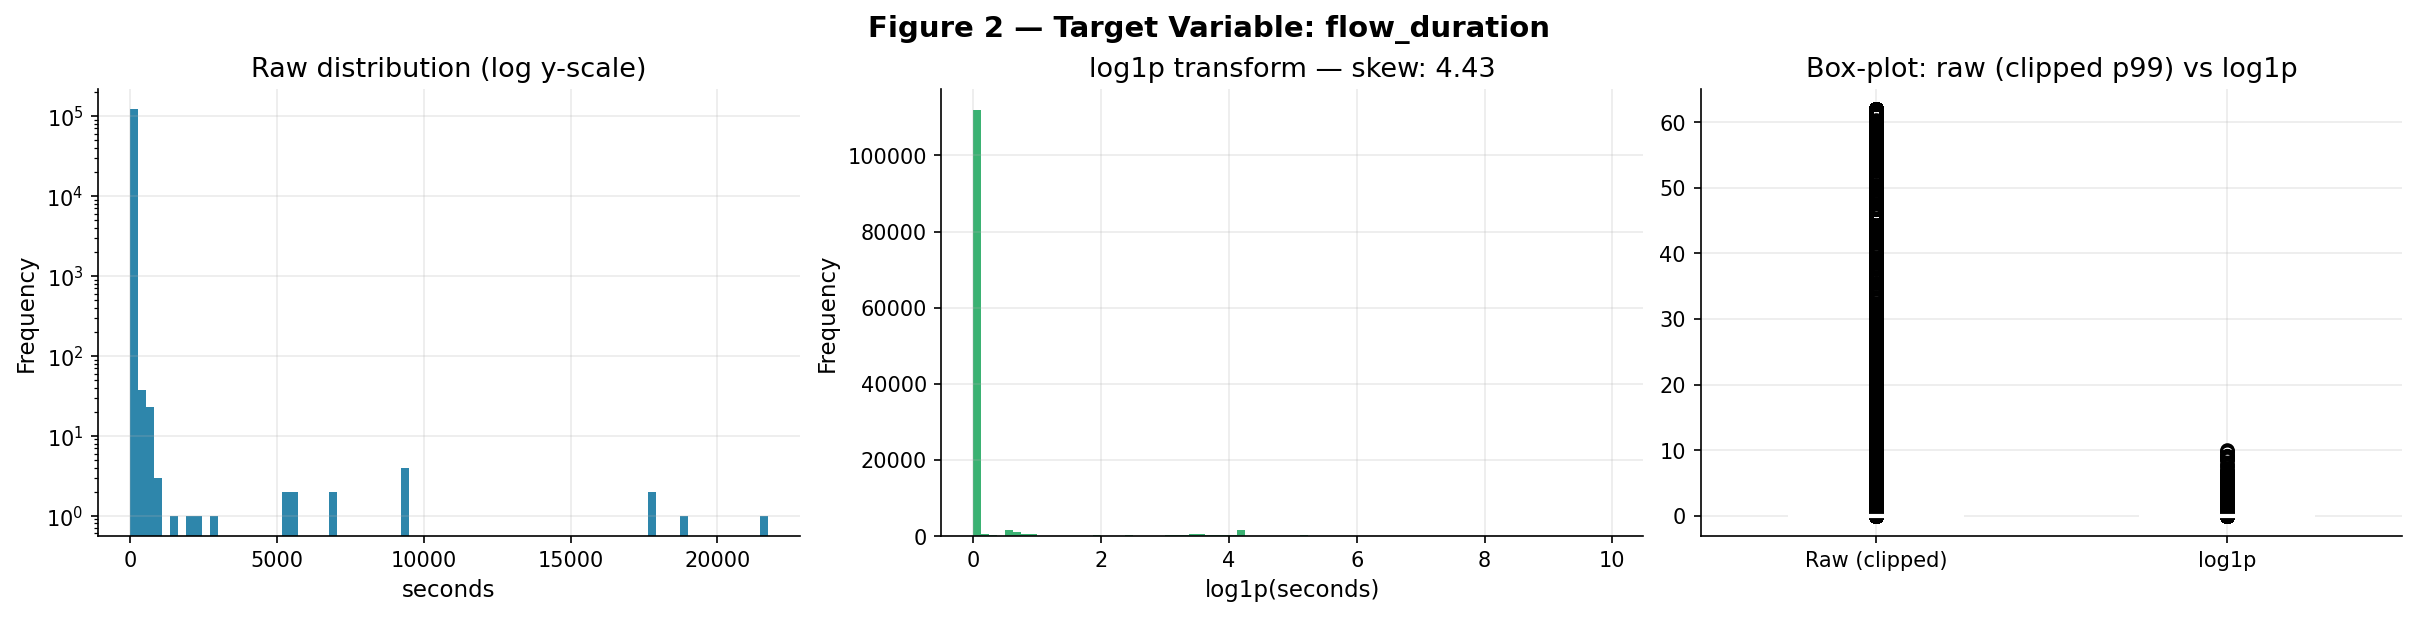

Raw   — min: 0.00e+00  max: 2.17e+04  skew: 120.96
log1p — min: 0.000  max: 9.986  skew: 4.43


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Figure 2 — Target Variable: flow_duration", fontweight="bold")

# Raw histogram (log-y for visibility)
axes[0].hist(df_raw[TARGET], bins=80, color=PALETTE[0], edgecolor="none")
axes[0].set(title="Raw distribution (log y-scale)",
            xlabel="seconds", ylabel="Frequency")
axes[0].set_yscale("log")

# After log1p
log_dur = np.log1p(df_raw[TARGET])
axes[1].hist(log_dur, bins=80, color=PALETTE[2], edgecolor="none")
axes[1].set(title=f"log1p transform — skew: {log_dur.skew():.2f}",
            xlabel="log1p(seconds)", ylabel="Frequency")

# Box-plot comparison
bp_data = [df_raw[TARGET].clip(upper=df_raw[TARGET].quantile(0.99)),
           log_dur]
bp = axes[2].boxplot(bp_data, patch_artist=True, widths=0.5,
                     medianprops=dict(color="white", linewidth=2))
for patch, col in zip(bp["boxes"], [PALETTE[0], PALETTE[2]]):
    patch.set_facecolor(col)
axes[2].set(title="Box-plot: raw (clipped p99) vs log1p",
            xticklabels=["Raw (clipped)", "log1p"])

savefig("02_target_distribution")
print(f"Raw   — min: {df_raw[TARGET].min():.2e}  max: {df_raw[TARGET].max():.2e}  "
      f"skew: {df_raw[TARGET].skew():.2f}")
print(f"log1p — min: {log_dur.min():.3f}  max: {log_dur.max():.3f}  "
      f"skew: {log_dur.skew():.2f}")

### 3.3 · Categorical Features

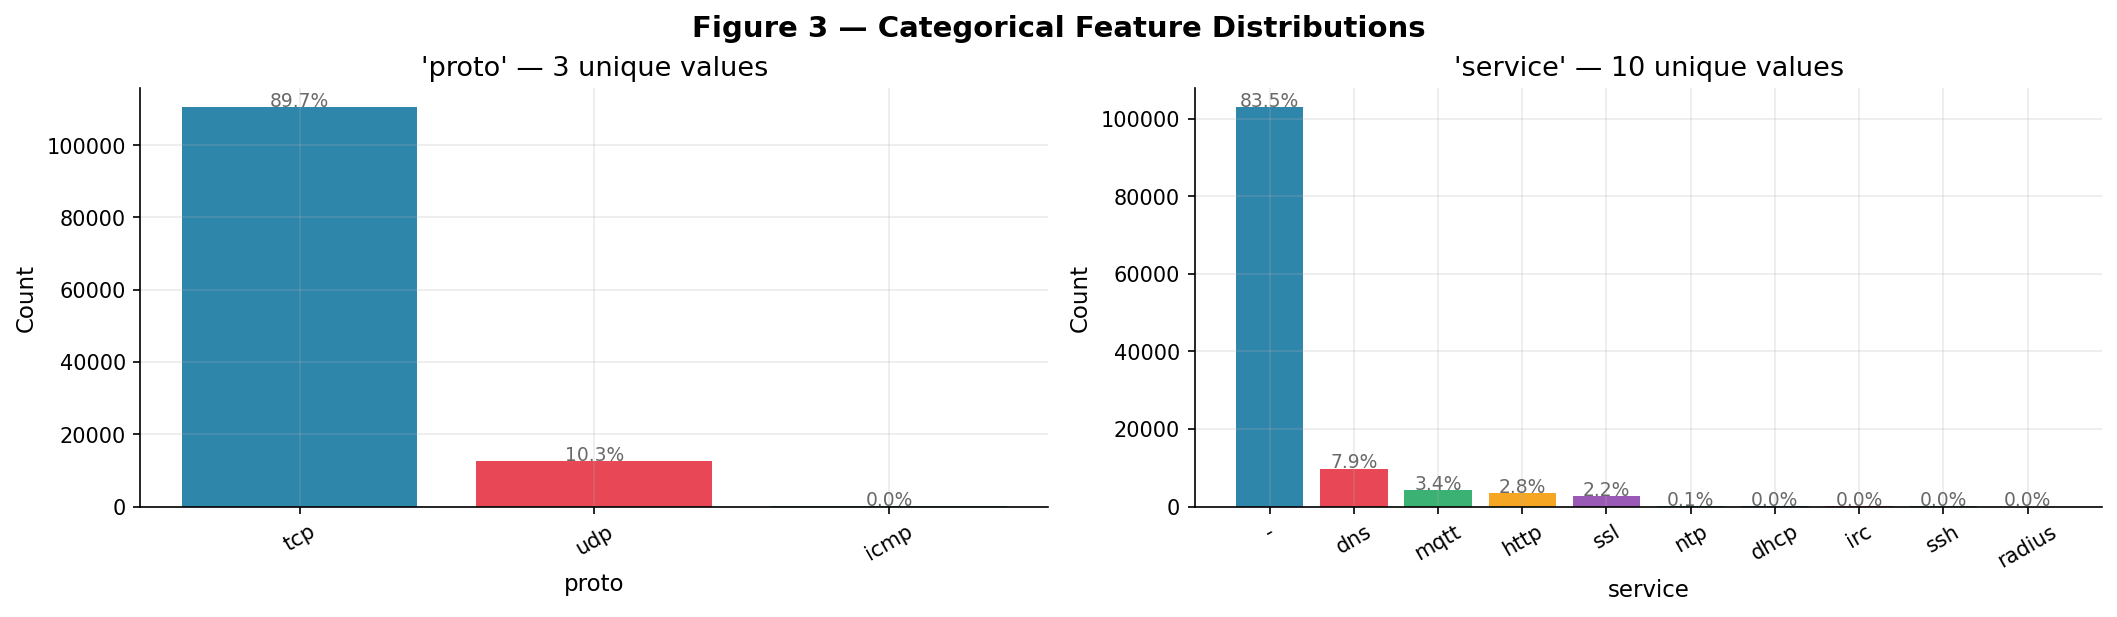

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Figure 3 — Categorical Feature Distributions", fontweight="bold")

for ax, col, pal in zip(axes, ["proto", "service"], [PALETTE, PALETTE]):
    vc = df_raw[col].value_counts()
    ax.bar(vc.index, vc.values, color=PALETTE[:len(vc)])
    ax.set(title=f"'{col}' — {vc.shape[0]} unique values",
           xlabel=col, ylabel="Count")
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(vc.values):
        ax.text(i, v + 200, f"{v/len(df_raw)*100:.1f}%",
                ha="center", fontsize=9, color="dimgrey")

savefig("03_categorical")

### 3.4 · Feature–Target Correlations (Top 20)

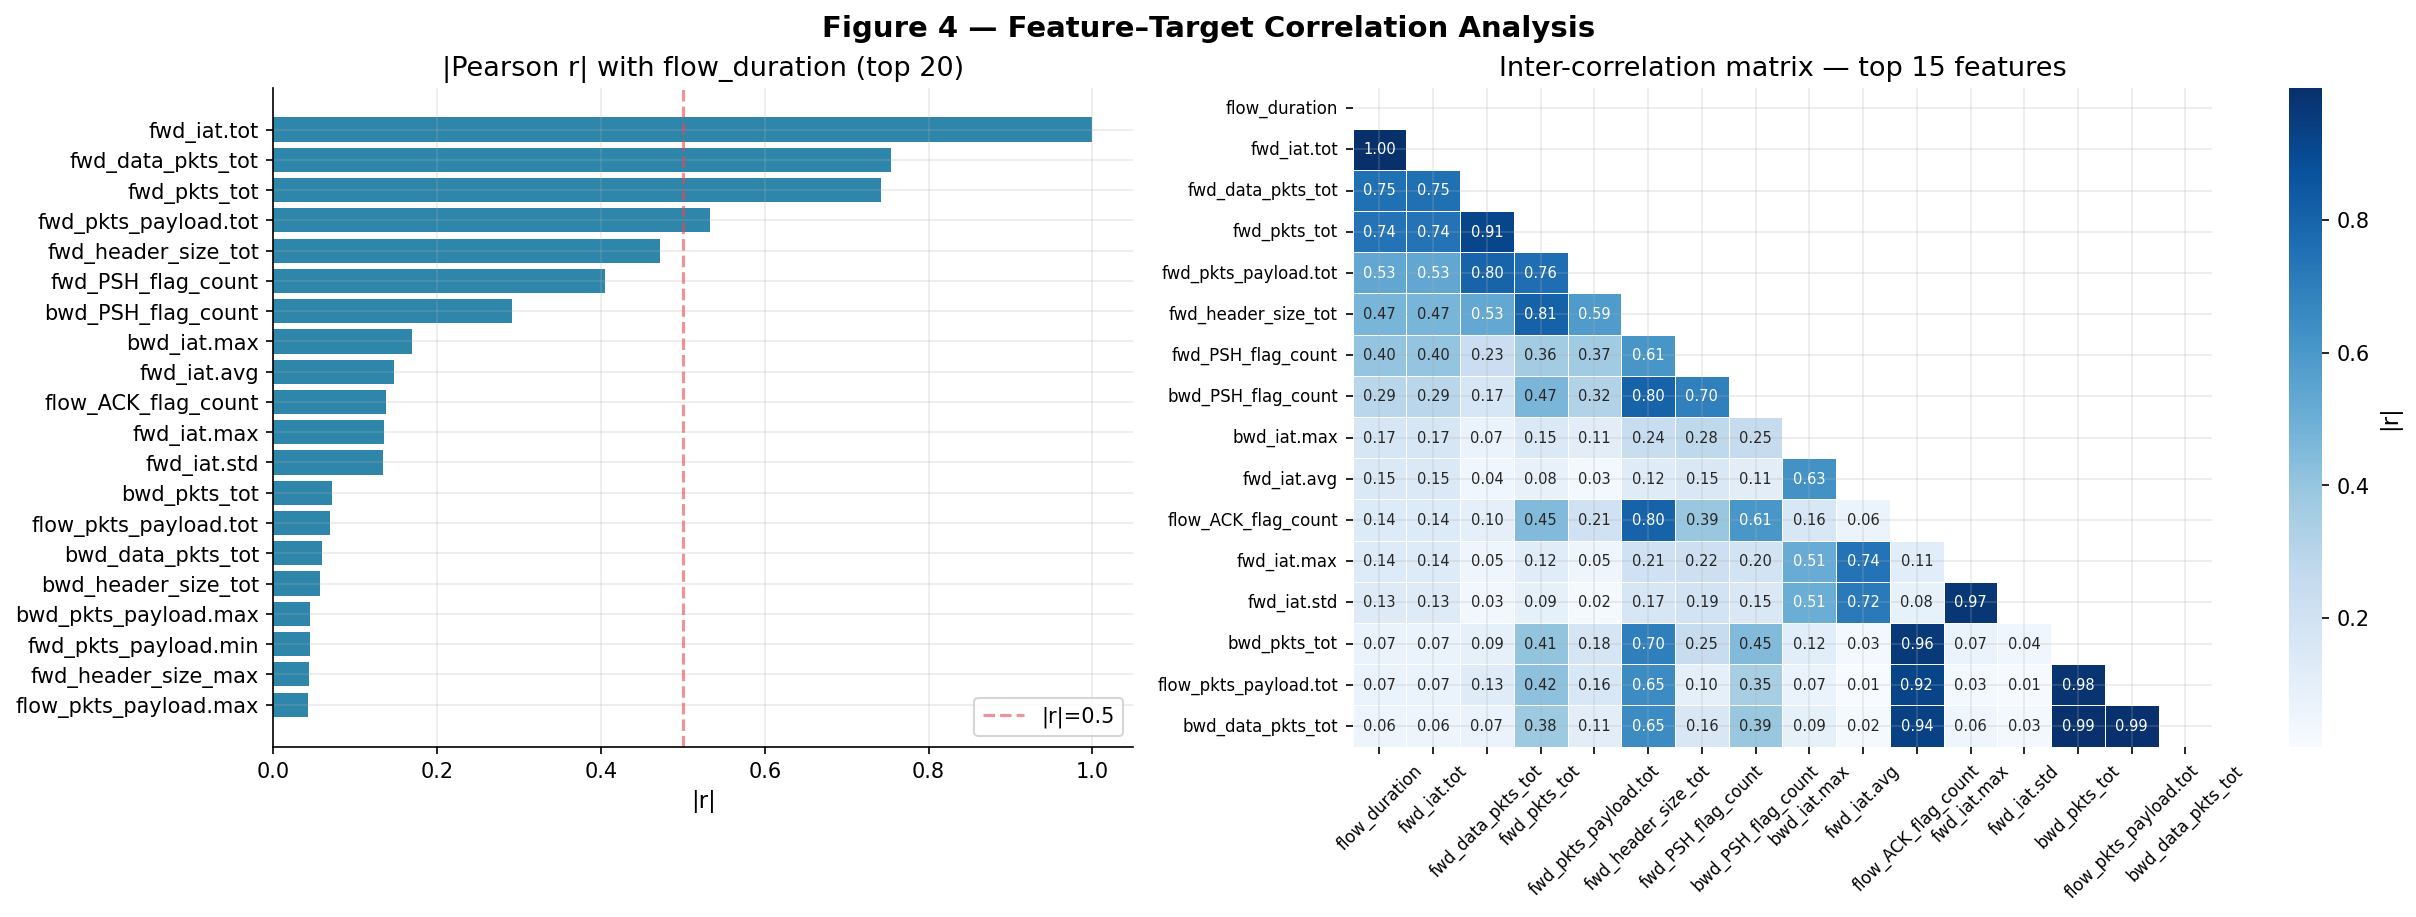

In [6]:
# Compute on raw numeric data
num_df = df_raw.select_dtypes(include=[np.number])
corr_target = num_df.corrwith(num_df[TARGET]).abs().sort_values(ascending=False)
top20_cols   = corr_target.head(21).index.tolist()  # includes TARGET itself

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Figure 4 — Feature–Target Correlation Analysis", fontweight="bold")

# Horizontal bar: |r| vs target
corr_vals = corr_target.drop(TARGET).head(20)
axes[0].barh(corr_vals.index[::-1], corr_vals.values[::-1], color=PALETTE[0])
axes[0].set(title="|Pearson r| with flow_duration (top 20)",
            xlabel="|r|", xlim=(0, 1.05))
axes[0].axvline(0.5, color=PALETTE[1], linestyle="--", alpha=0.6, label="|r|=0.5")
axes[0].legend()

# Heatmap of top-15 feature inter-correlations
top15 = corr_target.head(16).index.tolist()
hm = num_df[top15].corr().abs()
mask = np.triu(np.ones_like(hm, dtype=bool))
sns.heatmap(hm, mask=mask, ax=axes[1], cmap="Blues", annot=True, fmt=".2f",
            annot_kws={"size":7}, linewidths=0.3, cbar_kws={"label":"|r|"})
axes[1].set_title("Inter-correlation matrix — top 15 features")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].tick_params(axis="y", rotation=0,  labelsize=8)

savefig("04_correlations")

### 3.5 · Distribution of Top Predictors vs Target

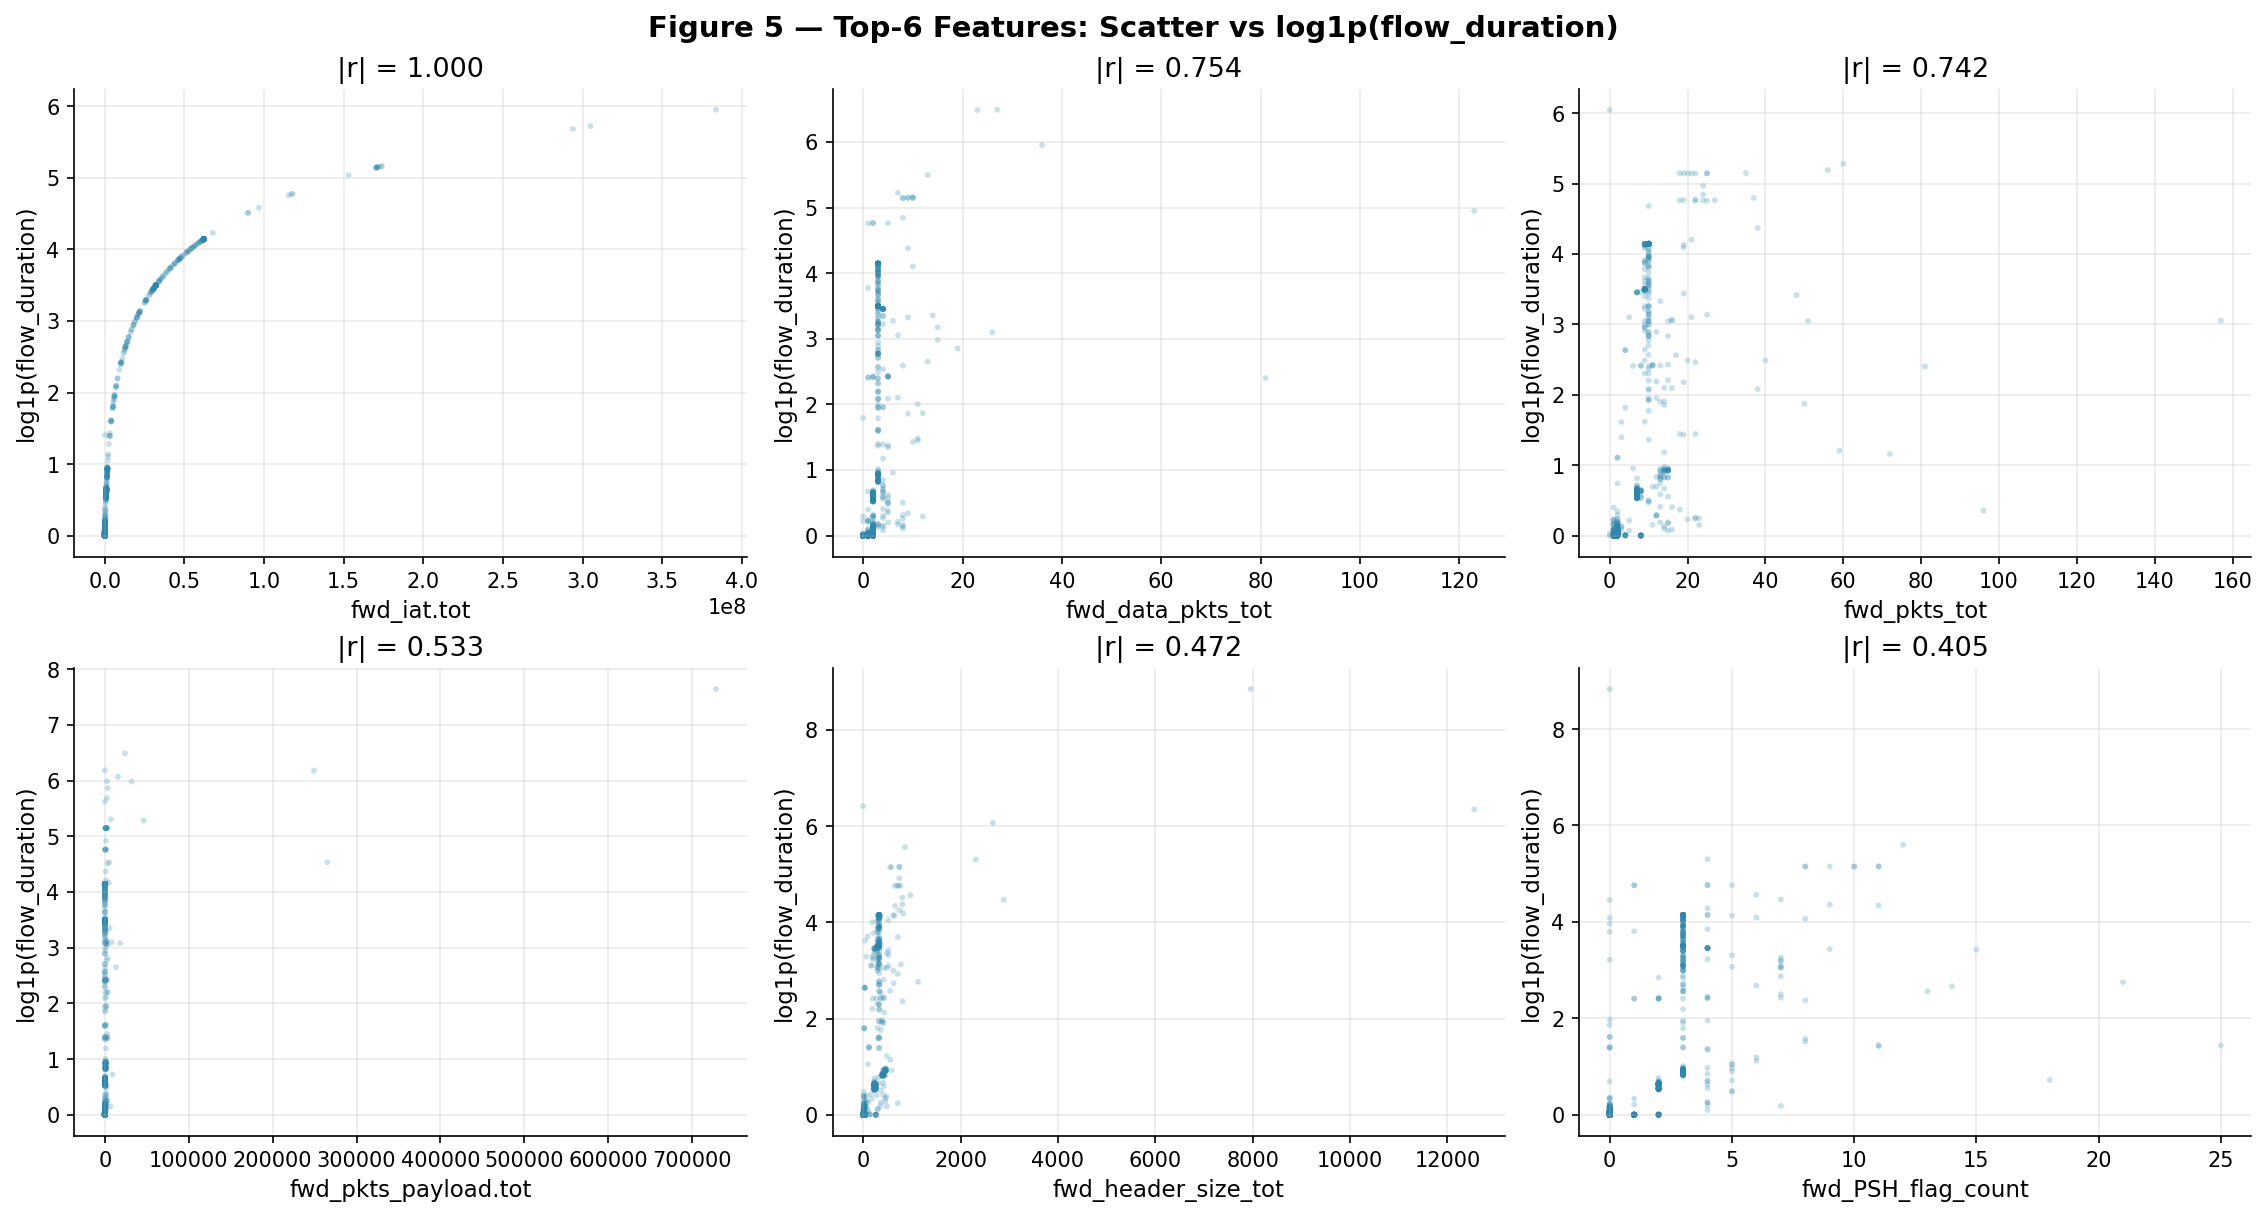

Scatter plots use 5,000-row random sample for clarity.


In [7]:
top6 = corr_target.drop(TARGET).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Figure 5 — Top-6 Features: Scatter vs log1p(flow_duration)",
             fontweight="bold")
log_y = np.log1p(df_raw[TARGET])

for ax, feat in zip(axes.flat, top6):
    sample_idx = np.random.choice(len(df_raw), size=5000, replace=False)
    x_vals = df_raw[feat].values[sample_idx]
    y_vals = log_y.values[sample_idx]
    ax.scatter(x_vals, y_vals, alpha=0.25, s=8, color=PALETTE[0], edgecolors="none")
    ax.set(xlabel=feat, ylabel="log1p(flow_duration)",
           title=f"|r| = {corr_target[feat]:.3f}")

savefig("05_top_predictors")
print("Scatter plots use 5,000-row random sample for clarity.")

## 4 · Preprocessing Pipeline

In [8]:
# ── 4.1 Deduplicate ──────────────────────────────────────────────
df = df_raw.copy()
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {n_before - len(df):,} duplicates  →  {len(df):,} rows remain")

# ── 4.2 Label-encode categorical columns ─────────────────────────
le_proto   = LabelEncoder(); df["proto"]   = le_proto.fit_transform(df["proto"].astype(str))
le_service = LabelEncoder(); df["service"] = le_service.fit_transform(df["service"].astype(str))

# ── 4.3 Separate features / target; log1p the target ─────────────
y       = np.log1p(df[TARGET].values)
X_raw_p = df.drop(columns=[TARGET]).copy()

# ── 4.4 StandardScaler ───────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw_p), columns=X_raw_p.columns)

print(f"Feature matrix : {X_scaled.shape}")
print(f"Target (log1p) : min={y.min():.3f}  max={y.max():.3f}  "
      f"mean={y.mean():.3f}  std={y.std():.3f}")

Removed 5,202 duplicates  →  117,915 rows remain
Feature matrix : (117915, 50)
Target (log1p) : min=0.000  max=9.986  mean=0.212  std=0.823


## 5 · Research-Driven Feature Selection

The feature-selection pipeline follows a staged approach that avoids arbitrary dimensionality choices:

```
50 raw features
  └─ Stage A: Variance filter          (drop constants)
  └─ Stage B: Correlation pruning      (drop redundant, |r|>0.95)
       → Pruned baseline (N_B features)
  └─ Stage C: Method comparison        (Pearson vs MI vs GB-importance)
  └─ Stage D: K-sweep on best method   (validate R² vs K curve)
  └─ Stage E: 3 progressive subsets    (Mild / Moderate / Optimal)
```

**No arbitrary K = 20 jump.** Every reduction level is justified by the sweep curve.

### 5.1 · Stage A — Low-Variance Filter

Features before variance filter : 50
Near-constant (dropped)         : 1  →  ['bwd_URG_flag_count']
Features after variance filter  : 49


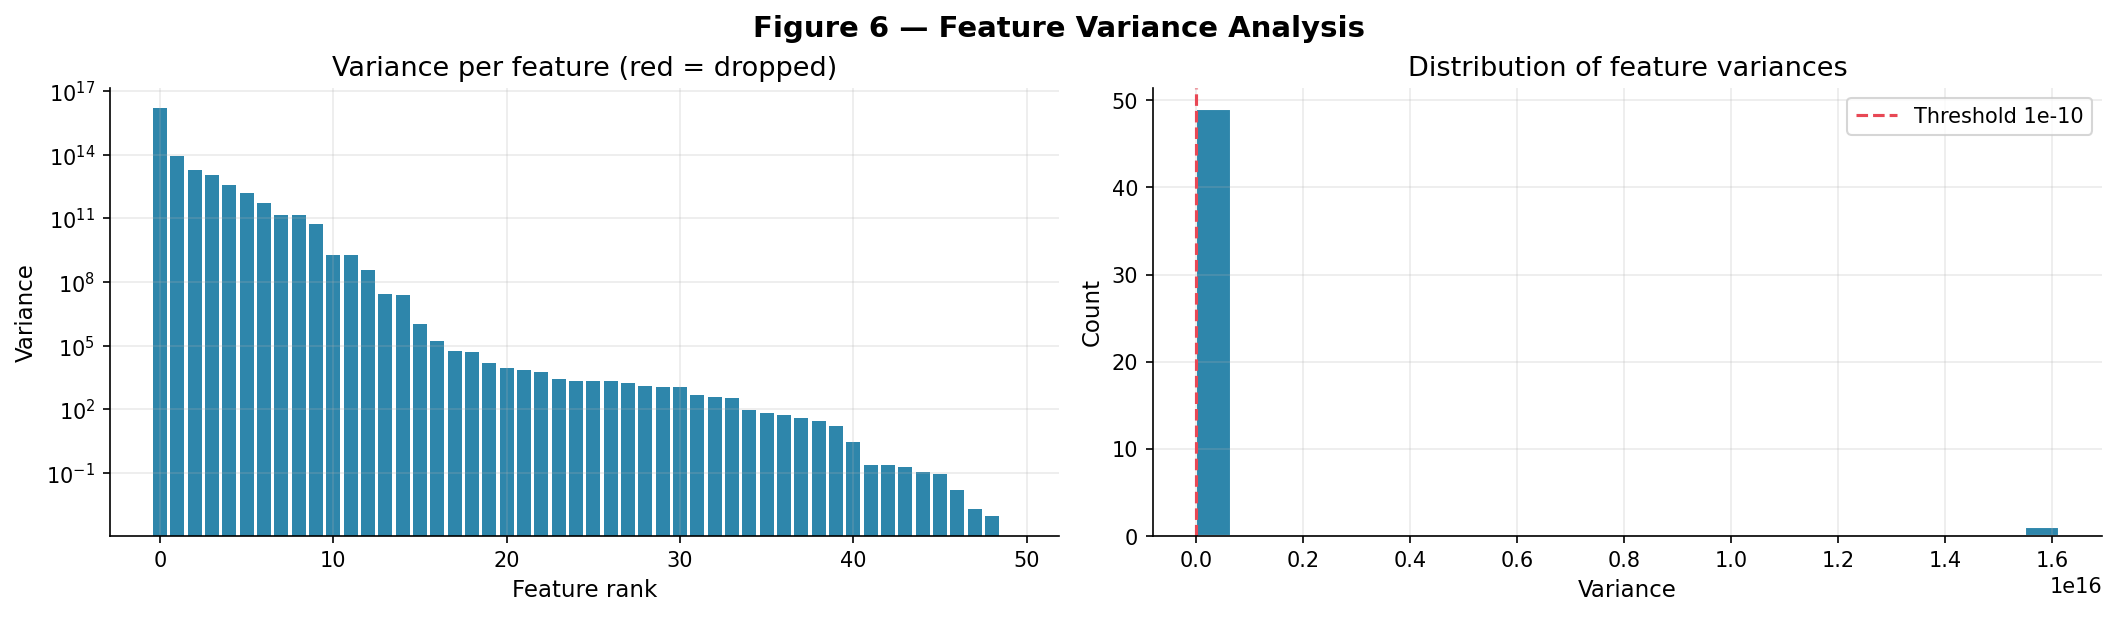

In [9]:
# Drop features with near-zero variance in the raw (pre-scaled) data
raw_var = X_raw_p.var()
near_const = raw_var[raw_var < 1e-10].index.tolist()

print(f"Features before variance filter : {X_raw_p.shape[1]}")
print(f"Near-constant (dropped)         : {len(near_const)}  →  {near_const}")

X_vf = X_scaled.drop(columns=near_const)
print(f"Features after variance filter  : {X_vf.shape[1]}")

# ── Visualise variance spread ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Figure 6 — Feature Variance Analysis", fontweight="bold")

sorted_var = raw_var.sort_values(ascending=False)
colors_var = [PALETTE[1] if c in near_const else PALETTE[0]
              for c in sorted_var.index]
axes[0].bar(range(len(sorted_var)), sorted_var.values, color=colors_var)
axes[0].set(title="Variance per feature (red = dropped)",
            xlabel="Feature rank", ylabel="Variance")
axes[0].set_yscale("log")

# Histogram of variances
axes[1].hist(sorted_var.values, bins=25, color=PALETTE[0], edgecolor="white")
axes[1].axvline(1e-10, color=PALETTE[1], linestyle="--", label="Threshold 1e-10")
axes[1].set(title="Distribution of feature variances",
            xlabel="Variance", ylabel="Count")
axes[1].legend()

savefig("06_variance_filter")

### 5.2 · Stage B — Correlation Pruning  (`|r| > 0.95`)

In [10]:
CORR_THRESH = 0.95

corr_matrix   = X_vf.corr().abs()
target_corr   = X_vf.corrwith(pd.Series(y)).abs()

to_drop = set()
col_list = list(X_vf.columns)
for i, c1 in enumerate(col_list):
    if c1 in to_drop: continue
    for c2 in col_list[i+1:]:
        if c2 in to_drop: continue
        if corr_matrix.loc[c1, c2] > CORR_THRESH:
            # keep whichever has stronger target correlation
            if target_corr[c1] < target_corr[c2]:
                to_drop.add(c1); break
            else:
                to_drop.add(c2)

print(f"Features before pruning : {X_vf.shape[1]}")
print(f"Dropped (|r|>{CORR_THRESH}) : {len(to_drop)}")
for f in sorted(to_drop):
    print(f"  ✗ {f:35s} (target |r| = {target_corr[f]:.4f})")

X_pruned = X_vf.drop(columns=list(to_drop))
N_PRUNED = X_pruned.shape[1]
print(f"\nFeatures remaining (PRUNED BASELINE) : {N_PRUNED}")

Features before pruning : 49
Dropped (|r|>0.95) : 10
  ✗ bwd_data_pkts_tot                   (target |r| = 0.0844)
  ✗ bwd_header_size_min                 (target |r| = 0.3728)
  ✗ bwd_header_size_tot                 (target |r| = 0.1061)
  ✗ bwd_pkts_payload.std                (target |r| = 0.3242)
  ✗ bwd_pkts_payload.tot                (target |r| = 0.0458)
  ✗ bwd_pkts_per_sec                    (target |r| = 0.2436)
  ✗ bwd_pkts_tot                        (target |r| = 0.1112)
  ✗ flow_pkts_payload.max               (target |r| = 0.3013)
  ✗ flow_pkts_per_sec                   (target |r| = 0.2436)
  ✗ fwd_iat.std                         (target |r| = 0.8469)

Features remaining (PRUNED BASELINE) : 39


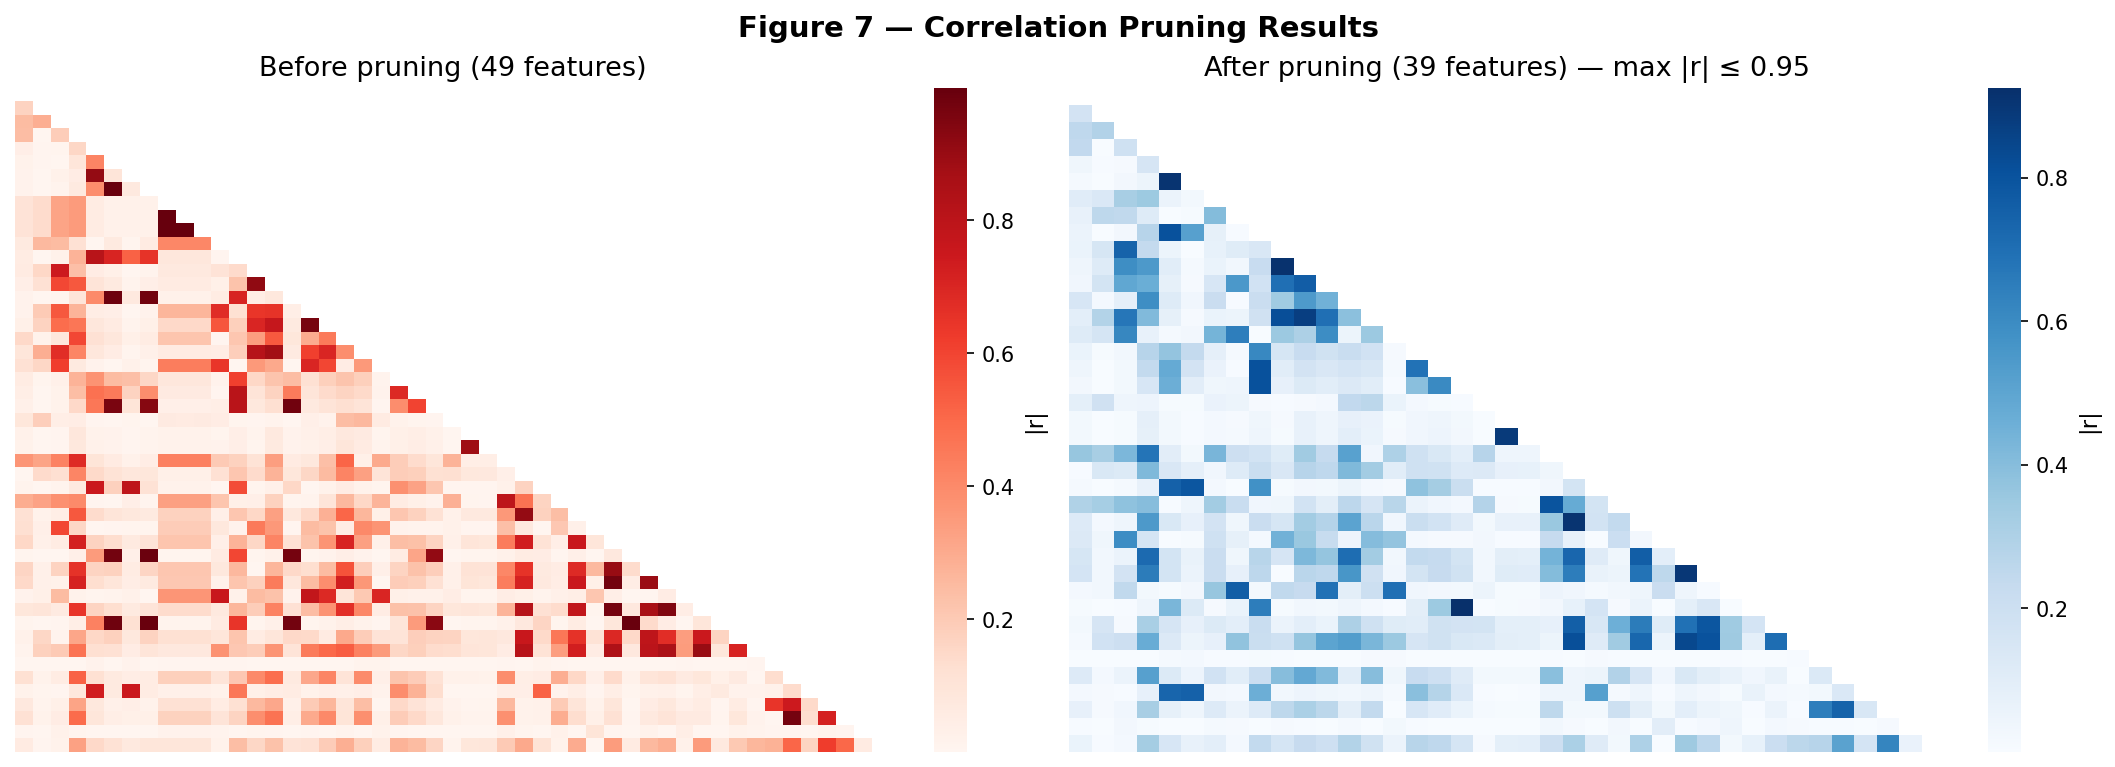

In [11]:
# ── Visualise pruning ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 7 — Correlation Pruning Results", fontweight="bold")

# Before pruning: full correlation matrix (top-left triangle)
mask = np.triu(np.ones_like(X_vf.corr(), dtype=bool))
sns.heatmap(X_vf.corr().abs(), ax=axes[0], mask=mask, cmap="Reds",
            cbar_kws={"label":"|r|"}, linewidths=0.0, xticklabels=False, yticklabels=False)
axes[0].set_title(f"Before pruning ({X_vf.shape[1]} features)")

# After pruning
mask2 = np.triu(np.ones_like(X_pruned.corr(), dtype=bool))
sns.heatmap(X_pruned.corr().abs(), ax=axes[1], mask=mask2, cmap="Blues",
            cbar_kws={"label":"|r|"}, linewidths=0.0, xticklabels=False, yticklabels=False)
axes[1].set_title(f"After pruning ({N_PRUNED} features) — max |r| ≤ {CORR_THRESH}")

savefig("07_correlation_pruning")

### 5.3 · Stage C — Three Ranking Methods Compared

In [12]:
# ── Pearson ───────────────────────────────────────────────────────
pearson_scores  = X_pruned.corrwith(pd.Series(y)).abs().sort_values(ascending=False)
pearson_ranking = pearson_scores.index.tolist()

# ── Mutual Information ────────────────────────────────────────────
print("Computing Mutual Information (may take ~30 s on full dataset) …")
t0 = time.time()
mi_vals    = mutual_info_regression(X_pruned.values, y, random_state=SEED)
print(f"  done in {time.time()-t0:.1f}s")
mi_scores  = pd.Series(mi_vals, index=X_pruned.columns).sort_values(ascending=False)
mi_ranking = mi_scores.index.tolist()

# ── Gradient-Boosting importance ─────────────────────────────────
print("Fitting GB for feature importance …")
t0 = time.time()
gb_ranker  = GradientBoostingRegressor(n_estimators=80, max_depth=4, random_state=SEED)
gb_ranker.fit(X_pruned.values, y)
print(f"  done in {time.time()-t0:.1f}s")
gb_scores  = pd.Series(gb_ranker.feature_importances_,
                       index=X_pruned.columns).sort_values(ascending=False)
gb_ranking = gb_scores.index.tolist()

print(f"\nTop-5  Pearson  : {pearson_ranking[:5]}")
print(f"Top-5  MI       : {mi_ranking[:5]}")
print(f"Top-5  GB-Imp   : {gb_ranking[:5]}")

Computing Mutual Information (may take ~30 s on full dataset) …
  done in 35.9s
Fitting GB for feature importance …
  done in 21.6s

Top-5  Pearson  : ['fwd_iat.max', 'service', 'fwd_header_size_max', 'fwd_iat.avg', 'bwd_header_size_max']
Top-5  MI       : ['fwd_pkts_per_sec', 'flow_pkts_payload.avg', 'fwd_iat.avg', 'flow_pkts_payload.std', 'fwd_iat.tot']
Top-5  GB-Imp   : ['fwd_iat.tot', 'bwd_iat.max', 'fwd_iat.max', 'fwd_pkts_per_sec', 'bwd_pkts_payload.min']


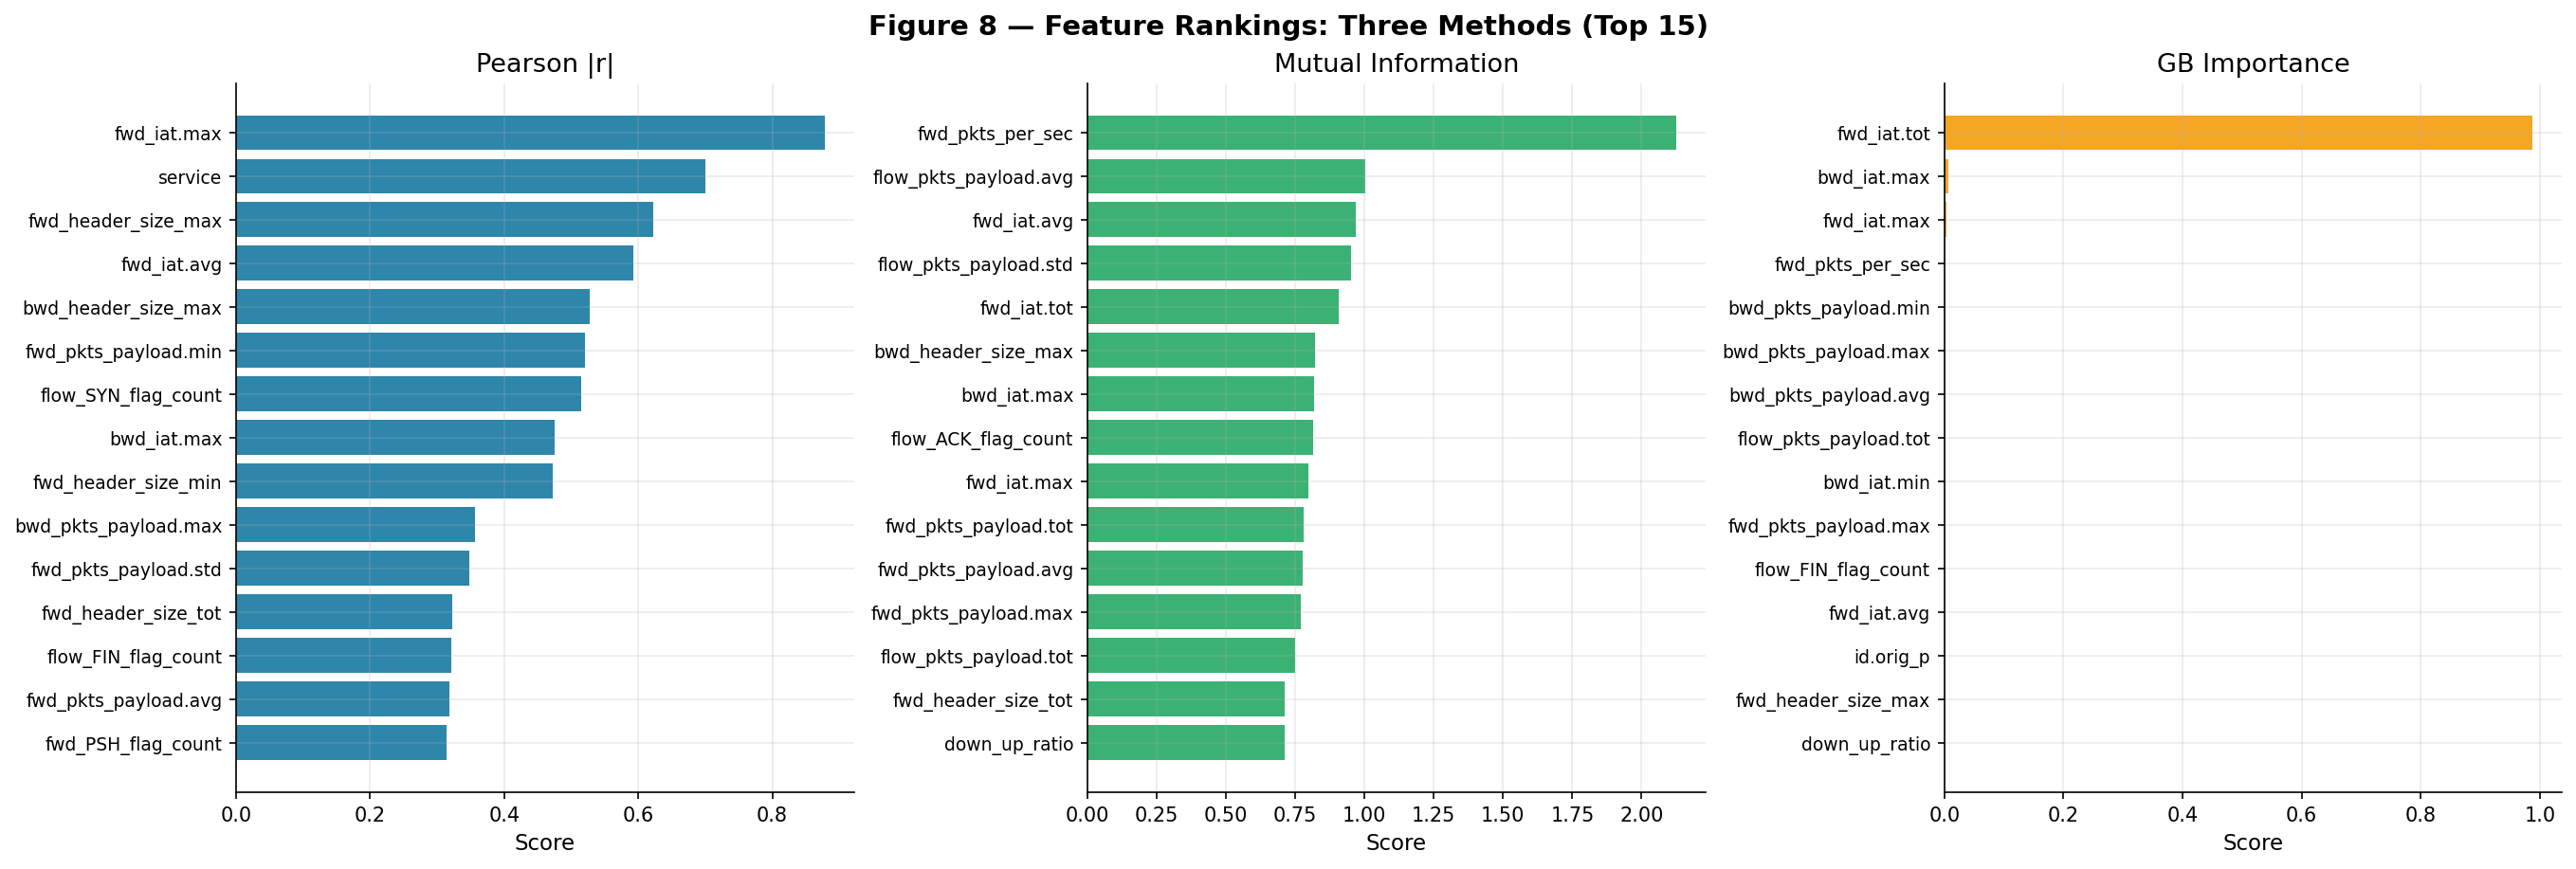

In [13]:
# ── Side-by-side importance bars (top 15 per method) ─────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Figure 8 — Feature Rankings: Three Methods (Top 15)", fontweight="bold")

method_info = [
    ("Pearson |r|",         pearson_scores, PALETTE[0]),
    ("Mutual Information",  mi_scores,      PALETTE[2]),
    ("GB Importance",       gb_scores,      PALETTE[3]),
]
for ax, (title, scores, col) in zip(axes, method_info):
    top = scores.head(15)
    ax.barh(top.index[::-1], top.values[::-1], color=col, edgecolor="none")
    ax.set(title=title, xlabel="Score")
    ax.tick_params(axis="y", labelsize=9)

savefig("08_feature_rankings")

In [14]:
# Quick head-to-head: rank each method's ordering by validation R2 at full K
# using a light GB (80 estimators) for speed
X_tr_cmp, X_va_cmp, y_tr_cmp, y_va_cmp = train_test_split(
    X_pruned.values, y, test_size=0.2, random_state=SEED
)

method_r2 = {}
for name, ranking in [("Pearson", pearson_ranking),
                      ("MutualInfo", mi_ranking),
                      ("GB-Importance", gb_ranking)]:
    idx = [X_pruned.columns.get_loc(f) for f in ranking]
    m = GradientBoostingRegressor(n_estimators=80, max_depth=4, random_state=SEED)
    m.fit(X_tr_cmp[:, idx], y_tr_cmp)
    r2 = r2_score(y_va_cmp, m.predict(X_va_cmp[:, idx]))
    method_r2[name] = r2
    print(f"  {name:14s}  R2 = {r2:.4f}")

best_method_name = max(method_r2, key=method_r2.get)
best_ranking     = {"Pearson": pearson_ranking,
                    "MutualInfo": mi_ranking,
                    "GB-Importance": gb_ranking}[best_method_name]
print(f"\n→ Best ranking method : {best_method_name}")

  Pearson         R2 = 0.9998
  MutualInfo      R2 = 0.9997
  GB-Importance   R2 = 0.9998

→ Best ranking method : GB-Importance


### 5.4 · Stage D — K-Sweep: Choosing Reduction Levels

In [15]:
# Sweep K across the range using the best ranking method
K_CANDIDATES = sorted(set(
    list(range(5, N_PRUNED + 1, 3)) + [N_PRUNED]
))
print(f"Sweeping {len(K_CANDIDATES)} values of K on {best_method_name} ranking …")

sweep_r2 = []
t0 = time.time()
for K in K_CANDIDATES:
    idx = [X_pruned.columns.get_loc(f) for f in best_ranking[:K]]
    m = GradientBoostingRegressor(n_estimators=80, max_depth=4, random_state=SEED)
    m.fit(X_tr_cmp[:, idx], y_tr_cmp)
    r2 = r2_score(y_va_cmp, m.predict(X_va_cmp[:, idx]))
    sweep_r2.append(r2)
print(f"Sweep completed in {time.time()-t0:.1f}s")

sweep_df = pd.DataFrame({"K": K_CANDIDATES, "R2": sweep_r2})
MAX_R2 = max(sweep_r2)
print(f"\nPeak R2 = {MAX_R2:.4f}  at K = {K_CANDIDATES[sweep_r2.index(MAX_R2)]}")

Sweeping 13 values of K on GB-Importance ranking …
Sweep completed in 177.1s

Peak R2 = 0.9998  at K = 39


In [16]:
# ── Identify the 3 progressive reduction points ──────────────────
# We want 3 levels that together show a clear progression:
#   Mild     : first K where R2 ≥ MAX_R2 - 0.001  (very minimal loss)
#   Moderate : first K where R2 ≥ MAX_R2 - 0.003  (small loss)
#   Optimal  : first K where R2 ≥ MAX_R2 - 0.005  (aggressive but acceptable)
THRESHOLDS = {"Mild-Reduction":    0.001,
              "Moderate-Reduction":0.003,
              "Optimal-Reduction": 0.005}

levels = {}
for label, eps in THRESHOLDS.items():
    for K, r2 in zip(K_CANDIDATES, sweep_r2):
        if r2 >= MAX_R2 - eps:
            levels[label] = K
            print(f"  {label:22s}  K = {K:3d}  R2={r2:.4f}  "
                  f"(Delta from max = {r2-MAX_R2:+.4f})")
            break

# Ensure the 3 K values are distinct and ordered
k_vals = sorted(set(levels.values()))
if len(k_vals) < 3:
    # pad with evenly spaced fallbacks
    step = max(1, (N_PRUNED - k_vals[0]) // (4 - len(k_vals)))
    for i in range(3 - len(k_vals)):
        k_vals.append(k_vals[-1] + step)
    k_vals = sorted(set(k_vals))[:3]

K_MILD, K_MOD, K_OPT = k_vals[0], k_vals[1], k_vals[2]
print(f"\n→ Final K values :  Mild={K_MILD}  Moderate={K_MOD}  Optimal={K_OPT}")
print(f"→ Baseline        :  {N_PRUNED} features")
print(f"→ Reductions      :  {N_PRUNED-K_MILD} / {N_PRUNED-K_MOD} / {N_PRUNED-K_OPT} features dropped")

  Mild-Reduction          K =   5  R2=0.9998  (Delta from max = -0.0001)
  Moderate-Reduction      K =   5  R2=0.9998  (Delta from max = -0.0001)
  Optimal-Reduction       K =   5  R2=0.9998  (Delta from max = -0.0001)

→ Final K values :  Mild=5  Moderate=16  Optimal=27
→ Baseline        :  39 features
→ Reductions      :  34 / 23 / 12 features dropped


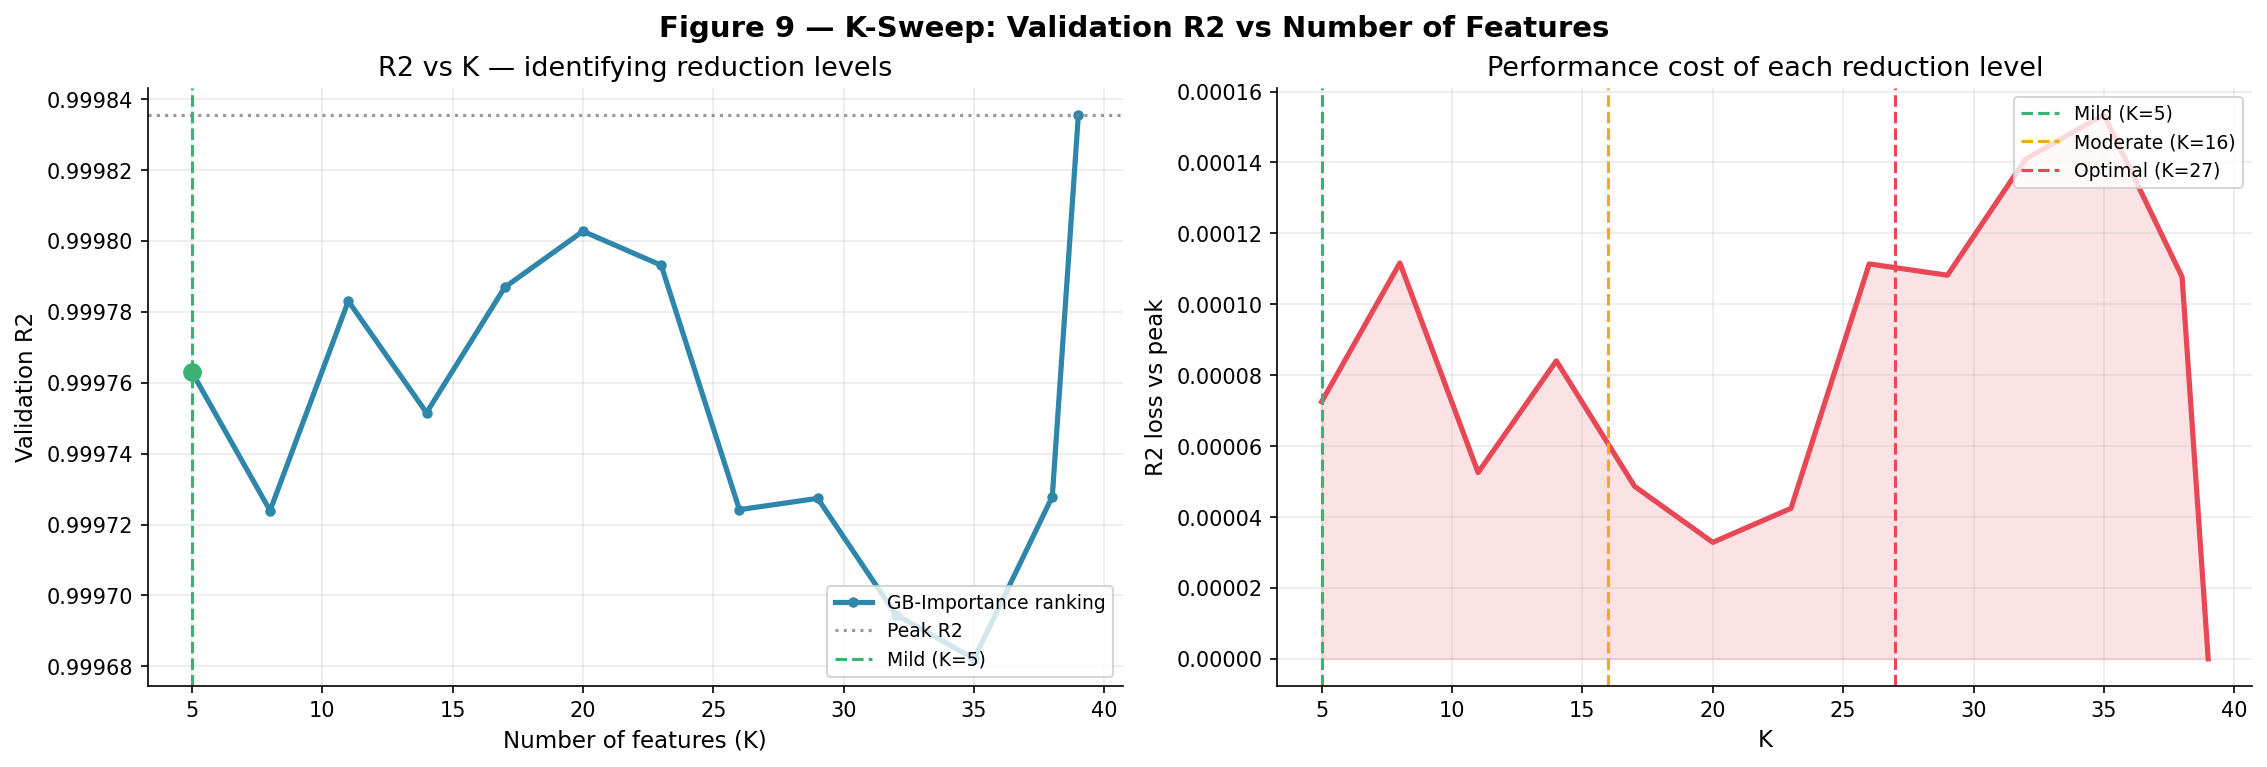

In [17]:
# ── K-sweep visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Figure 9 — K-Sweep: Validation R2 vs Number of Features",
             fontweight="bold")

# Main curve
axes[0].plot(K_CANDIDATES, sweep_r2, color=PALETTE[0], linewidth=2.5,
             marker="o", markersize=4, label=f"{best_method_name} ranking")
axes[0].axhline(MAX_R2, color="grey", linestyle=":", alpha=0.8, label="Peak R2")
colors_lvl = [PALETTE[2], PALETTE[3], PALETTE[1]]
names_lvl  = [f"Mild (K={K_MILD})", f"Moderate (K={K_MOD})", f"Optimal (K={K_OPT})"]
for K, col, lbl in zip([K_MILD, K_MOD, K_OPT], colors_lvl, names_lvl):
    r2v = sweep_df.loc[sweep_df.K == K, "R2"].values
    if len(r2v):
        axes[0].axvline(K, color=col, linestyle="--", linewidth=1.5, label=lbl)
        axes[0].plot(K, r2v[0], "o", color=col, markersize=8, zorder=5)
axes[0].set(xlabel="Number of features (K)",
            ylabel="Validation R2",
            title="R2 vs K — identifying reduction levels")
axes[0].legend(loc="lower right", fontsize=9)

# Zoom: show reduction loss vs K
delta = [MAX_R2 - r for r in sweep_r2]
axes[1].plot(K_CANDIDATES, delta, color=PALETTE[1], linewidth=2.5)
axes[1].fill_between(K_CANDIDATES, 0, delta, alpha=0.15, color=PALETTE[1])
for K, col, lbl in zip([K_MILD, K_MOD, K_OPT], colors_lvl, names_lvl):
    axes[1].axvline(K, color=col, linestyle="--", linewidth=1.5, label=lbl)
axes[1].set(xlabel="K", ylabel="R2 loss vs peak",
            title="Performance cost of each reduction level")
axes[1].legend(loc="upper right", fontsize=9)

savefig("09_k_sweep")

### 5.5 · Stage E — Final Feature Subsets

In [18]:
feature_subsets = {
    "Baseline-All"       : best_ranking[:N_PRUNED],   # all 39 pruned features
    f"Mild   (K={K_MILD})"     : best_ranking[:K_MILD],
    f"Moderate (K={K_MOD})"    : best_ranking[:K_MOD],
    f"Optimal (K={K_OPT})"     : best_ranking[:K_OPT],
}
# clean keys for dict lookups
FS_NAMES = list(feature_subsets.keys())
print("Feature subsets finalised:\n")
for name, feats in feature_subsets.items():
    print(f"  {name:22s}: {len(feats):3d} features  "
          f"({'—' if 'Baseline' in name else f'-{N_PRUNED-len(feats)} vs baseline'})")

Feature subsets finalised:

  Baseline-All          :  39 features  (—)
  Mild   (K=5)          :   5 features  (-34 vs baseline)
  Moderate (K=16)       :  16 features  (-23 vs baseline)
  Optimal (K=27)        :  27 features  (-12 vs baseline)


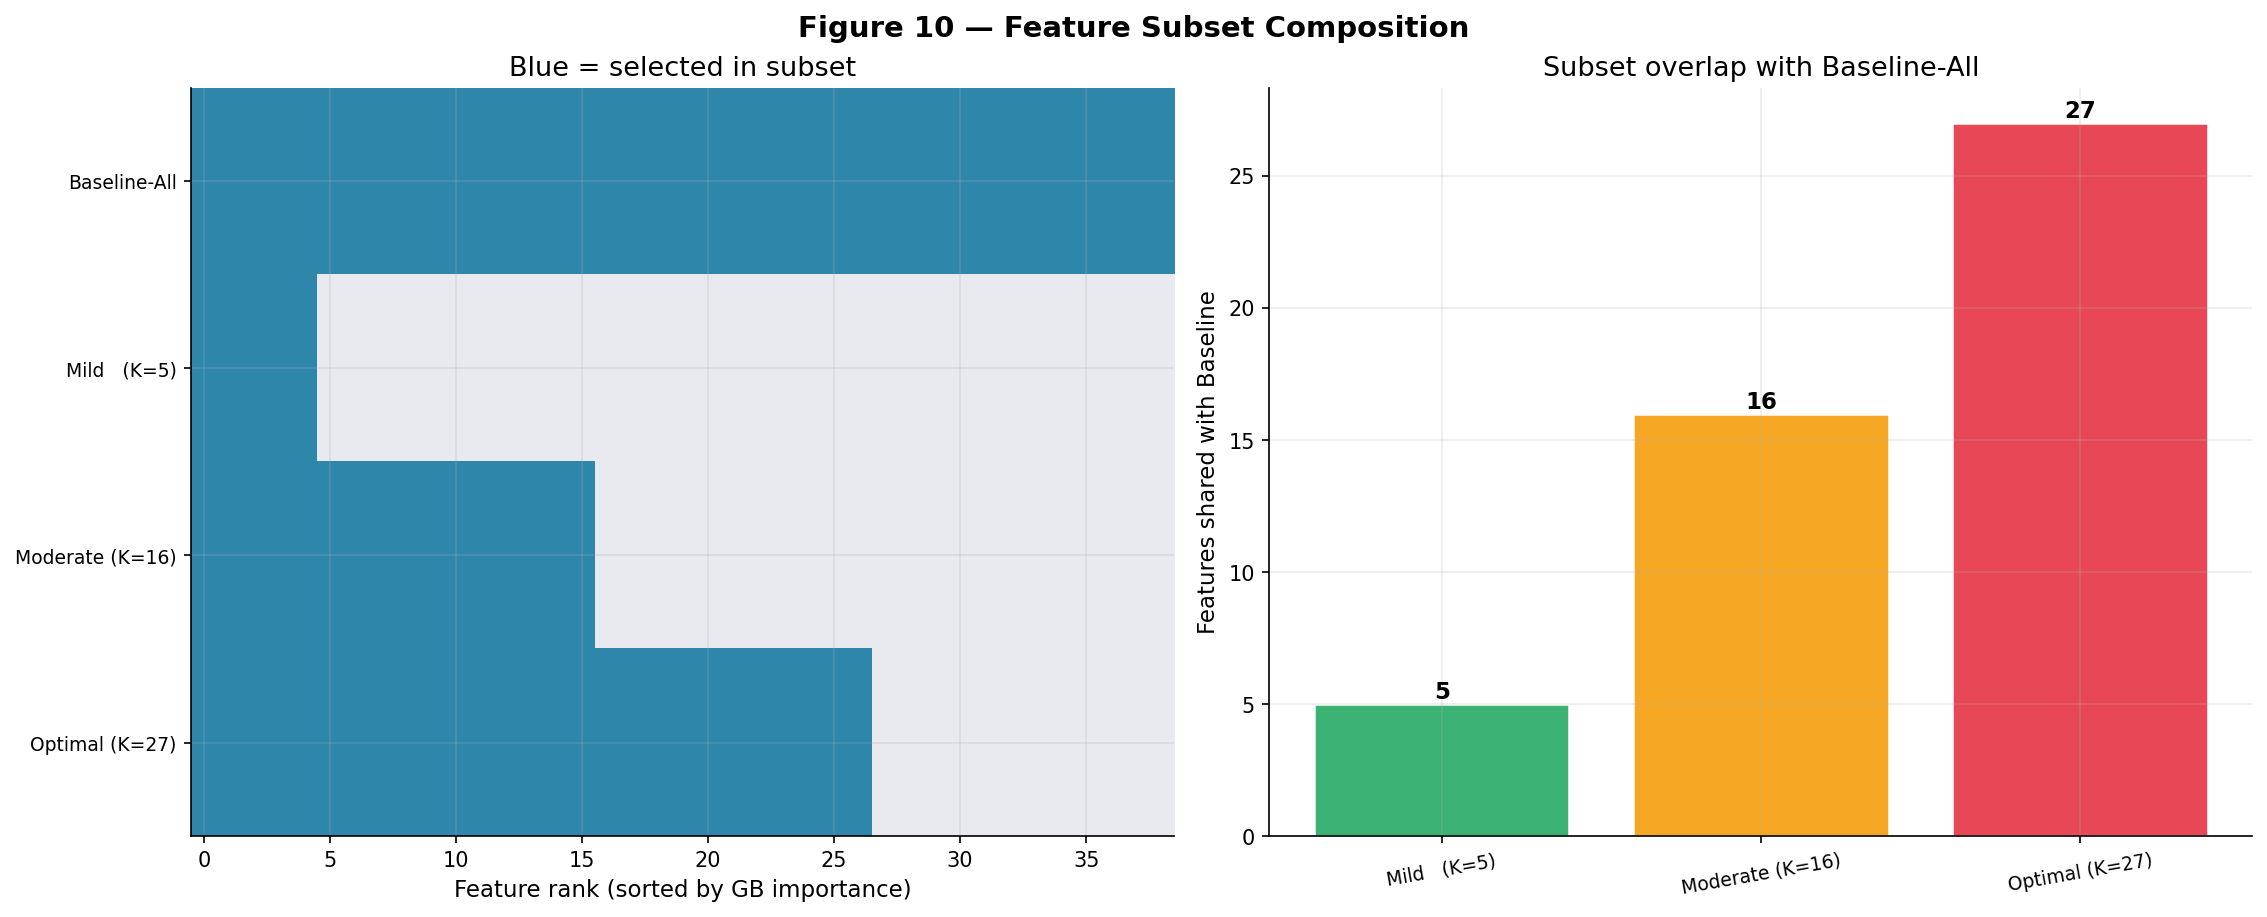

In [19]:
# ── FS visualisation: overlap + selection grid ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Figure 10 — Feature Subset Composition", fontweight="bold")

# Feature presence grid
all_feats = best_ranking[:N_PRUNED]
grid = pd.DataFrame(index=all_feats, columns=list(feature_subsets.keys()), dtype=int)
for name, feats in feature_subsets.items():
    grid[name] = grid.index.isin(feats).astype(int)

cmap_grid = matplotlib.colors.ListedColormap(["#E8EAF0", PALETTE[0]])
im = axes[0].imshow(grid.values.T, aspect="auto", cmap=cmap_grid,
                    interpolation="none", vmin=0, vmax=1)
axes[0].set_yticks(range(len(FS_NAMES)))
axes[0].set_yticklabels([n.strip() for n in FS_NAMES], fontsize=9)
axes[0].set_xticks(range(0, N_PRUNED, 5))
axes[0].set_xticklabels(range(0, N_PRUNED, 5))
axes[0].set(xlabel="Feature rank (sorted by GB importance)",
            title="Blue = selected in subset")

# Bar: how many features each subset shares with Baseline
baseline_set = set(feature_subsets["Baseline-All"])
overlap = {name: len(set(feats) & baseline_set)
           for name, feats in feature_subsets.items() if "Baseline" not in name}
axes[1].bar(range(len(overlap)), list(overlap.values()),
            color=colors_lvl, edgecolor="white", linewidth=1.2)
axes[1].set_xticks(range(len(overlap)))
axes[1].set_xticklabels([n.strip() for n in overlap.keys()], fontsize=9, rotation=10)
axes[1].set(ylabel="Features shared with Baseline",
            title="Subset overlap with Baseline-All")
for i, v in enumerate(overlap.values()):
    axes[1].text(i, v + 0.2, str(v), ha="center", fontweight="bold")

savefig("10_subset_composition")

## 6 · Train / Test Split (80 / 20)

In [20]:
splits = {}
for name, feats in feature_subsets.items():
    Xtr, Xte, ytr, yte = train_test_split(
        X_pruned[feats].values, y, test_size=0.2, random_state=SEED
    )
    splits[name] = (Xtr, Xte, ytr, yte)
    print(f"{name:24s} | train={Xtr.shape}  test={Xte.shape}")

Baseline-All             | train=(94332, 39)  test=(23583, 39)
Mild   (K=5)             | train=(94332, 5)  test=(23583, 5)
Moderate (K=16)          | train=(94332, 16)  test=(23583, 16)
Optimal (K=27)           | train=(94332, 27)  test=(23583, 27)


## 7 · Evaluation Helper

In [21]:
def evaluate(y_true, y_pred):
    return {
        "MAE"    : round(mean_absolute_error(y_true, y_pred),  4),
        "MSE"    : round(mean_squared_error(y_true, y_pred),   4),
        "RMSE"   : round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "R2"     : round(r2_score(y_true, y_pred),             4),
        "ExplVar": round(explained_variance_score(y_true, y_pred), 4),
    }

results      = []
predictions  = {}

## 8 · Classical ML Models  (4 models × 4 subsets = 16 runs)

### 8.1 · Gradient Boosting Regressor

In [22]:
for fs_name, (Xtr, Xte, ytr, yte) in splits.items():
    model = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                      learning_rate=0.1, random_state=SEED)
    t0 = time.time(); model.fit(Xtr, ytr); ft = time.time() - t0
    yp = model.predict(Xte)
    m  = evaluate(yte, yp)
    m.update({"Model":"Gradient Boosting","FeatureSet":fs_name,"FitTime":round(ft,2)})
    results.append(m); predictions[f"Gradient Boosting|{fs_name}"] = (yte, yp)
    print(f"  {fs_name[:22]:22s} R2={m['R2']:.4f}  MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  ({ft:.1f}s)")

  Baseline-All           R2=0.9999  MAE=0.0010  RMSE=0.0095  (52.4s)
  Mild   (K=5)           R2=0.9998  MAE=0.0010  RMSE=0.0117  (11.6s)
  Moderate (K=16)        R2=0.9998  MAE=0.0010  RMSE=0.0108  (34.1s)
  Optimal (K=27)         R2=0.9999  MAE=0.0010  RMSE=0.0096  (44.3s)


### 8.2 · Extra Trees Regressor

In [23]:
for fs_name, (Xtr, Xte, ytr, yte) in splits.items():
    model = ExtraTreesRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
    t0 = time.time(); model.fit(Xtr, ytr); ft = time.time() - t0
    yp = model.predict(Xte)
    m  = evaluate(yte, yp)
    m.update({"Model":"Extra Trees","FeatureSet":fs_name,"FitTime":round(ft,2)})
    results.append(m); predictions[f"Extra Trees|{fs_name}"] = (yte, yp)
    print(f"  {fs_name[:22]:22s} R2={m['R2']:.4f}  MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  ({ft:.1f}s)")

  Baseline-All           R2=0.9992  MAE=0.0010  RMSE=0.0236  (63.4s)
  Mild   (K=5)           R2=0.9996  MAE=0.0006  RMSE=0.0163  (8.7s)
  Moderate (K=16)        R2=0.9993  MAE=0.0009  RMSE=0.0220  (27.6s)
  Optimal (K=27)         R2=0.9993  MAE=0.0010  RMSE=0.0219  (45.4s)


### 8.3 · AdaBoost Regressor

In [24]:
for fs_name, (Xtr, Xte, ytr, yte) in splits.items():
    model = AdaBoostRegressor(n_estimators=150, learning_rate=0.1, random_state=SEED)
    t0 = time.time(); model.fit(Xtr, ytr); ft = time.time() - t0
    yp = model.predict(Xte)
    m  = evaluate(yte, yp)
    m.update({"Model":"AdaBoost","FeatureSet":fs_name,"FitTime":round(ft,2)})
    results.append(m); predictions[f"AdaBoost|{fs_name}"] = (yte, yp)
    print(f"  {fs_name[:22]:22s} R2={m['R2']:.4f}  MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  ({ft:.1f}s)")

  Baseline-All           R2=0.9902  MAE=0.0625  RMSE=0.0825  (52.4s)
  Mild   (K=5)           R2=0.9908  MAE=0.0577  RMSE=0.0799  (11.4s)
  Moderate (K=16)        R2=0.9909  MAE=0.0572  RMSE=0.0796  (25.5s)
  Optimal (K=27)         R2=0.9909  MAE=0.0575  RMSE=0.0796  (35.2s)


### 8.4 · Huber Regressor

In [25]:
for fs_name, (Xtr, Xte, ytr, yte) in splits.items():
    model = HuberRegressor(max_iter=500, alpha=0.001)
    t0 = time.time(); model.fit(Xtr, ytr); ft = time.time() - t0
    yp = model.predict(Xte)
    m  = evaluate(yte, yp)
    m.update({"Model":"Huber","FeatureSet":fs_name,"FitTime":round(ft,2)})
    results.append(m); predictions[f"Huber|{fs_name}"] = (yte, yp)
    print(f"  {fs_name[:22]:22s} R2={m['R2']:.4f}  MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  ({ft:.1f}s)")

  Baseline-All           R2=0.9153  MAE=0.0447  RMSE=0.2424  (29.5s)
  Mild   (K=5)           R2=0.8079  MAE=0.0847  RMSE=0.3652  (4.9s)
  Moderate (K=16)        R2=0.8659  MAE=0.0588  RMSE=0.3051  (19.3s)
  Optimal (K=27)         R2=0.9073  MAE=0.0537  RMSE=0.2536  (26.0s)


## 9 · Deep Learning Models  (2 models × 4 subsets = 8 runs)

Both models treat the feature vector as a short sequence `(K, 1)` — no ANN / DNN / MLP / LSTM / 1-D CNN used.  
Training: `batch_size=512`, up to 20 epochs, early stopping `patience=3`.

In [26]:
EPOCHS, BATCH, PAT = 20, 512, 3
early_stop = keras.callbacks.EarlyStopping(patience=PAT, restore_best_weights=True,
                                           monitor="val_loss")

def fresh_seed():
    tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

# Reshape for sequence models: (n, K) → (n, K, 1)
dl_splits = {k: (Xtr[..., None], Xte[..., None], ytr, yte)
             for k, (Xtr, Xte, ytr, yte) in splits.items()}

### 9.1 · Gated Recurrent Unit (GRU)

In [27]:
def build_gru(n_feat):
    inp = keras.Input(shape=(n_feat, 1))
    x = layers.GRU(64, return_sequences=True)(inp)
    x = layers.GRU(32)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model

gru_models = {}; gru_hist = {}
for fs_name, (Xtr, Xte, ytr, yte) in dl_splits.items():
    fresh_seed()
    m = build_gru(Xtr.shape[1])
    t0 = time.time()
    h = m.fit(Xtr, ytr, validation_split=0.1, epochs=EPOCHS, batch_size=BATCH,
              callbacks=[early_stop], verbose=0)
    ft = time.time() - t0
    yp = m.predict(Xte, verbose=0).ravel()
    met = evaluate(yte, yp)
    met.update({"Model":"GRU","FeatureSet":fs_name,"FitTime":round(ft,2)})
    results.append(met); predictions[f"GRU|{fs_name}"] = (yte, yp)
    gru_models[fs_name] = m; gru_hist[fs_name] = h.history
    print(f"  {fs_name[:22]:22s} R2={met['R2']:.4f}  MAE={met['MAE']:.4f}  "
          f"epochs={len(h.history['loss'])}  ({ft:.1f}s)")

  Baseline-All           R2=0.9813  MAE=0.0208  epochs=16  (29.2s)
  Mild   (K=5)           R2=0.9605  MAE=0.0623  epochs=3  (5.3s)
  Moderate (K=16)        R2=0.9432  MAE=0.0494  epochs=3  (7.1s)
  Optimal (K=27)         R2=0.9392  MAE=0.0484  epochs=3  (7.4s)


### 9.2 · Transformer Encoder (single block)

In [28]:
def build_transformer(n_feat, d=16, heads=4, ff=32):
    inp = keras.Input(shape=(n_feat, 1))
    x   = layers.Dense(d)(inp)
    pos = layers.Embedding(input_dim=n_feat, output_dim=d)(
              tf.range(start=0, limit=n_feat, delta=1))
    x   = x + pos
    att = layers.MultiHeadAttention(num_heads=heads, key_dim=d)(x, x)
    x1  = layers.LayerNormalization()(layers.Add()([x, att]))
    ff1 = layers.Dense(ff, activation="relu")(x1)
    ff2 = layers.Dense(d)(ff1)
    x2  = layers.LayerNormalization()(layers.Add()([x1, ff2]))
    p   = layers.GlobalAveragePooling1D()(x2)
    p   = layers.Dense(32, activation="relu")(p)
    p   = layers.Dropout(0.2)(p)
    out = layers.Dense(1)(p)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model

tx_models = {}; tx_hist = {}
for fs_name, (Xtr, Xte, ytr, yte) in dl_splits.items():
    fresh_seed()
    m = build_transformer(Xtr.shape[1])
    t0 = time.time()
    h = m.fit(Xtr, ytr, validation_split=0.1, epochs=EPOCHS, batch_size=BATCH,
              callbacks=[early_stop], verbose=0)
    ft = time.time() - t0
    yp = m.predict(Xte, verbose=0).ravel()
    met = evaluate(yte, yp)
    met.update({"Model":"Transformer","FeatureSet":fs_name,"FitTime":round(ft,2)})
    results.append(met); predictions[f"Transformer|{fs_name}"] = (yte, yp)
    tx_models[fs_name] = m; tx_hist[fs_name] = h.history
    print(f"  {fs_name[:22]:22s} R2={met['R2']:.4f}  MAE={met['MAE']:.4f}  "
          f"epochs={len(h.history['loss'])}  ({ft:.1f}s)")

  Baseline-All           R2=0.6954  MAE=0.1458  epochs=3  (16.0s)
  Mild   (K=5)           R2=0.9496  MAE=0.0659  epochs=3  (14.2s)
  Moderate (K=16)        R2=0.6708  MAE=0.1677  epochs=3  (14.0s)
  Optimal (K=27)         R2=0.7838  MAE=0.1456  epochs=3  (15.5s)


## 10 · Results Summary

In [29]:
results_df = (pd.DataFrame(results)
               .sort_values("R2", ascending=False)
               .reset_index(drop=True))

print(f"Total runs : {len(results_df)}")
results_df

Total runs : 24


,MAE,MSE,RMSE,R2,ExplVar,Model,FeatureSet,FitTime
0,0.0010,0.0001,0.0095,0.9999,0.9999,Gradient Boosting,Baseline-All,52.43
1,0.0010,0.0001,0.0096,0.9999,0.9999,Gradient Boosting,Optimal (K=27),44.28
2,0.0010,0.0001,0.0117,0.9998,0.9998,Gradient Boosting,Mild (K=5),11.63
3,0.0010,0.0001,0.0108,0.9998,0.9998,Gradient Boosting,Moderate (K=16),34.06
4,0.0006,0.0003,0.0163,0.9996,0.9996,Extra Trees,Mild (K=5),8.65
5,0.0009,0.0005,0.0220,0.9993,0.9993,Extra Trees,Moderate (K=16),27.59
6,0.0010,0.0005,0.0219,0.9993,0.9993,Extra Trees,Optimal (K=27),45.40
7,0.0010,0.0006,0.0236,0.9992,0.9992,Extra Trees,Baseline-All,63.35
8,0.0575,0.0063,0.0796,0.9909,0.9936,AdaBoost,Optimal (K=27),35.17
9,0.0572,0.0063,0.0796,0.9909,0.9935,AdaBoost,Moderate (K=16),25.53


In [30]:
# Best per model (for bar chart)
best_per = (results_df.loc[results_df.groupby("Model")["R2"].idxmax()]
                      .sort_values("R2", ascending=False)
                      .reset_index(drop=True))
print("Best result per algorithm:")
best_per[["Model","FeatureSet","R2","MAE","RMSE","FitTime"]]

Best result per algorithm:


,Model,FeatureSet,R2,MAE,RMSE,FitTime
0,Gradient Boosting,Baseline-All,0.9999,0.0010,0.0095,52.43
1,Extra Trees,Mild (K=5),0.9996,0.0006,0.0163,8.65
2,AdaBoost,Optimal (K=27),0.9909,0.0575,0.0796,35.17
3,GRU,Baseline-All,0.9813,0.0208,0.1139,29.19
4,Transformer,Mild (K=5),0.9496,0.0659,0.1870,14.25
5,Huber,Baseline-All,0.9153,0.0447,0.2424,29.46


In [31]:
# Dimensionality reduction benefit table
summary_rows = []
for model_name in results_df.Model.unique():
    sub = results_df[results_df.Model == model_name]
    base_row = sub[sub.FeatureSet == "Baseline-All"].iloc[0]
    best_red = sub[sub.FeatureSet != "Baseline-All"].sort_values("R2", ascending=False).iloc[0]
    summary_rows.append({
        "Model"            : model_name,
        "Baseline R2"      : base_row["R2"],
        "Best Reduced R2"  : best_red["R2"],
        "Best Subset"      : best_red["FeatureSet"].strip(),
        "DeltaR2"   : round(best_red["R2"] - base_row["R2"], 4),
        "Features"         : f"{N_PRUNED} → {len(feature_subsets[best_red['FeatureSet']])}",
    })
summary_df = pd.DataFrame(summary_rows).sort_values("Best Reduced R2", ascending=False).reset_index(drop=True)
print("Dimensionality reduction vs Baseline:")
summary_df

Dimensionality reduction vs Baseline:


,Model,Baseline R2,Best Reduced R2,Best Subset,DeltaR2,Features
0,Gradient Boosting,0.9999,0.9999,Optimal (K=27),0.0000,39 → 27
1,Extra Trees,0.9992,0.9996,Mild (K=5),0.0004,39 → 5
2,AdaBoost,0.9902,0.9909,Optimal (K=27),0.0007,39 → 27
3,GRU,0.9813,0.9605,Mild (K=5),-0.0208,39 → 5
4,Transformer,0.6954,0.9496,Mild (K=5),0.2542,39 → 5
5,Huber,0.9153,0.9073,Optimal (K=27),-0.0080,39 → 27


## 11 · Publication-Level Visualisations

All figures are saved to `figures/` automatically.

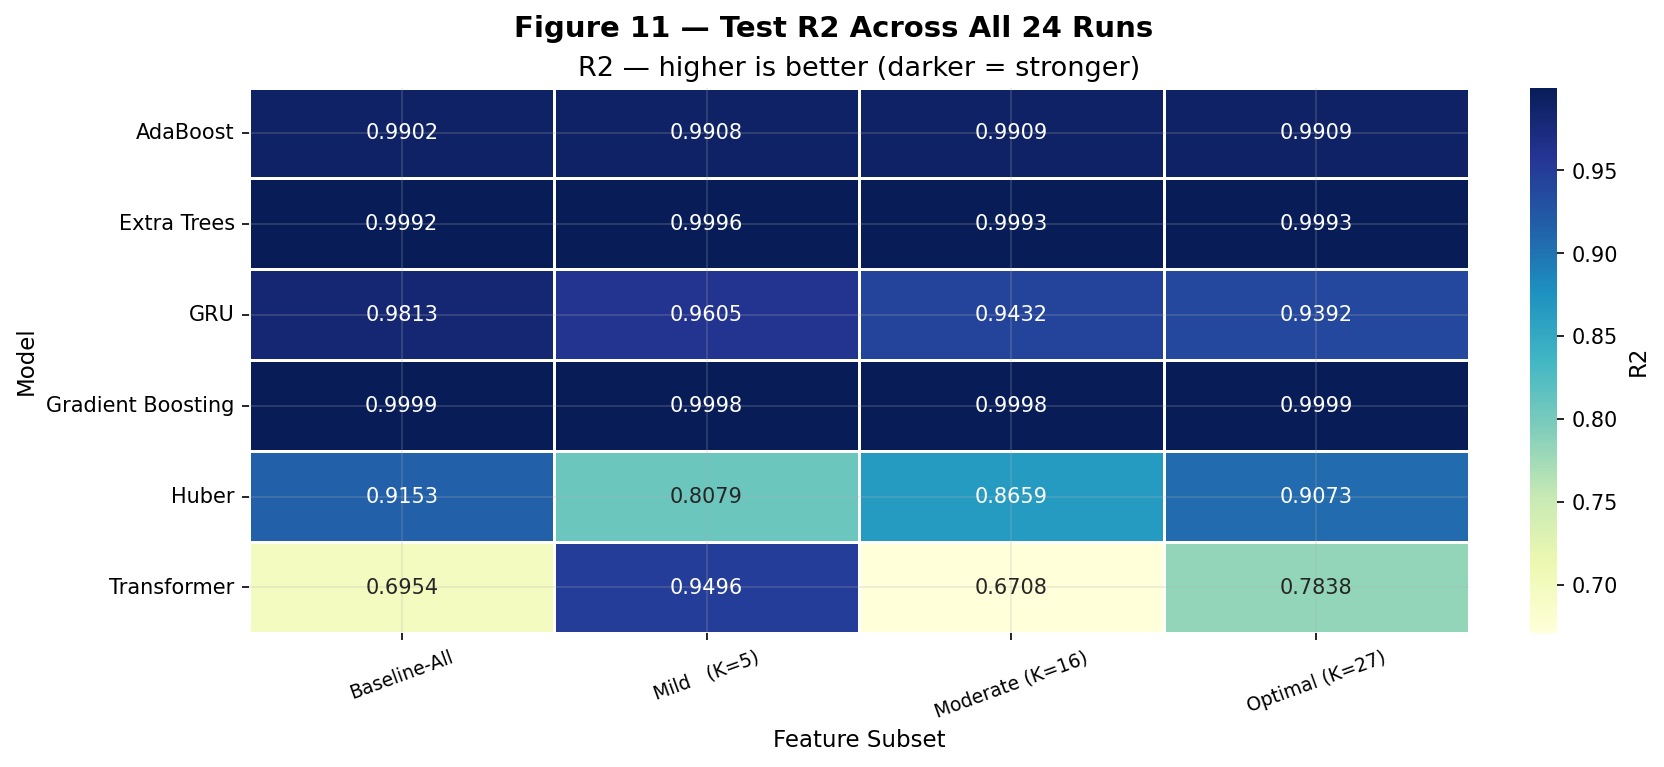

In [32]:
fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("Figure 11 — Test R2 Across All 24 Runs", fontweight="bold")

pivot = (results_df.pivot_table(index="Model", columns="FeatureSet", values="R2"))
# re-order columns: Baseline first, then progressive
col_order = ["Baseline-All"] + [c for c in pivot.columns if c != "Baseline-All"]
pivot = pivot[[c for c in col_order if c in pivot.columns]]
pivot.columns = [c.strip() for c in pivot.columns]

sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu", linewidths=0.5,
            cbar_kws={"label":"R2"}, annot_kws={"size":10}, ax=ax)
ax.set(xlabel="Feature Subset", ylabel="Model",
       title="R2 — higher is better (darker = stronger)")
ax.tick_params(axis="x", rotation=20, labelsize=9)

savefig("11_r2_heatmap")

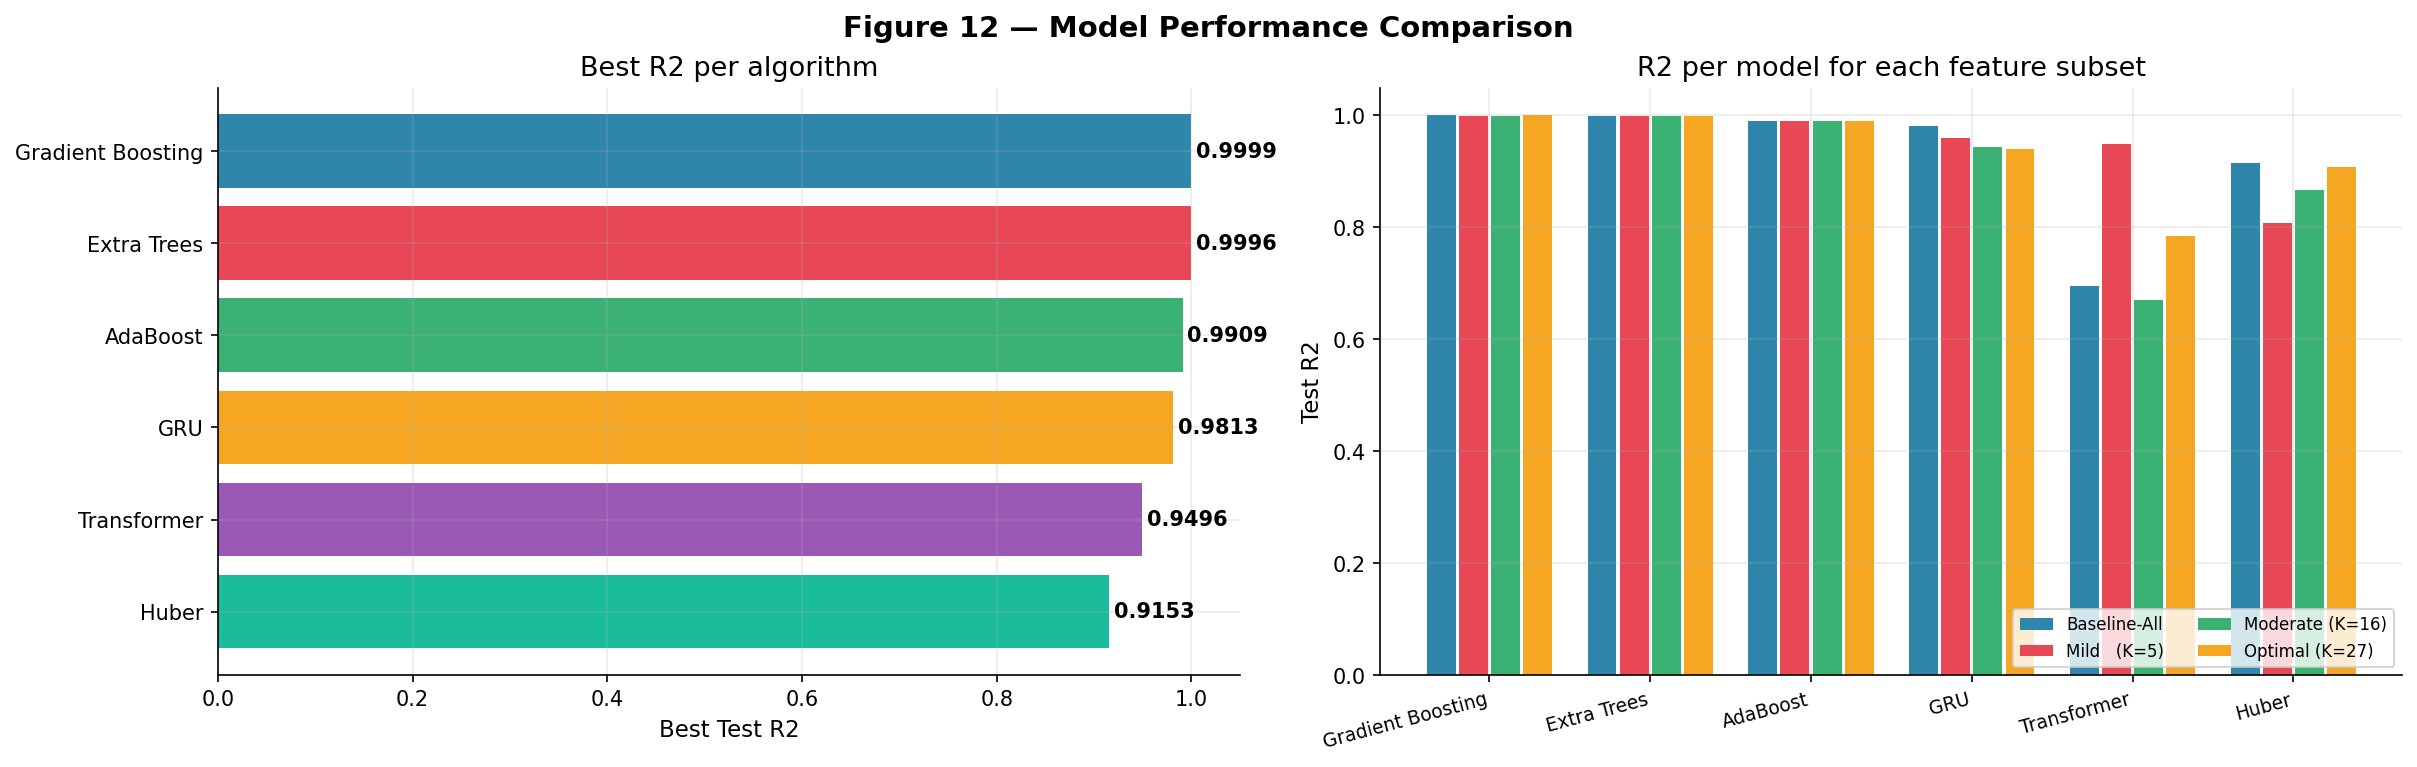

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Figure 12 — Model Performance Comparison", fontweight="bold")

# Left: best R2 per algorithm
colors_m = PALETTE[:len(best_per)]
bars = axes[0].barh(best_per["Model"], best_per["R2"], color=colors_m, edgecolor="none")
axes[0].set(xlabel="Best Test R2", title="Best R2 per algorithm", xlim=(0, 1.05))
axes[0].invert_yaxis()
for bar, v in zip(bars, best_per["R2"]):
    axes[0].text(v + 0.005, bar.get_y() + bar.get_height()/2,
                 f"{v:.4f}", va="center", fontsize=10, fontweight="bold")

# Right: R2 per model for each subset (grouped bar)
model_names = results_df.Model.unique().tolist()
fs_short    = [c.strip() for c in col_order if c in pivot.columns]
x = np.arange(len(model_names))
width = 0.8 / len(fs_short)
for i, fs in enumerate(fs_short):
    vals = [results_df[(results_df.Model==m) & (results_df.FeatureSet.str.strip()==fs)]["R2"].values
            for m in model_names]
    vals = [v[0] if len(v) else np.nan for v in vals]
    axes[1].bar(x + i*width, vals, width=width*0.9,
                label=fs, color=PALETTE[i % len(PALETTE)])
axes[1].set_xticks(x + width * (len(fs_short)/2 - 0.5))
axes[1].set_xticklabels(model_names, rotation=15, ha="right", fontsize=9)
axes[1].set(ylabel="Test R2", title="R2 per model for each feature subset")
axes[1].legend(loc="lower right", fontsize=8, ncol=2)

savefig("12_model_comparison")

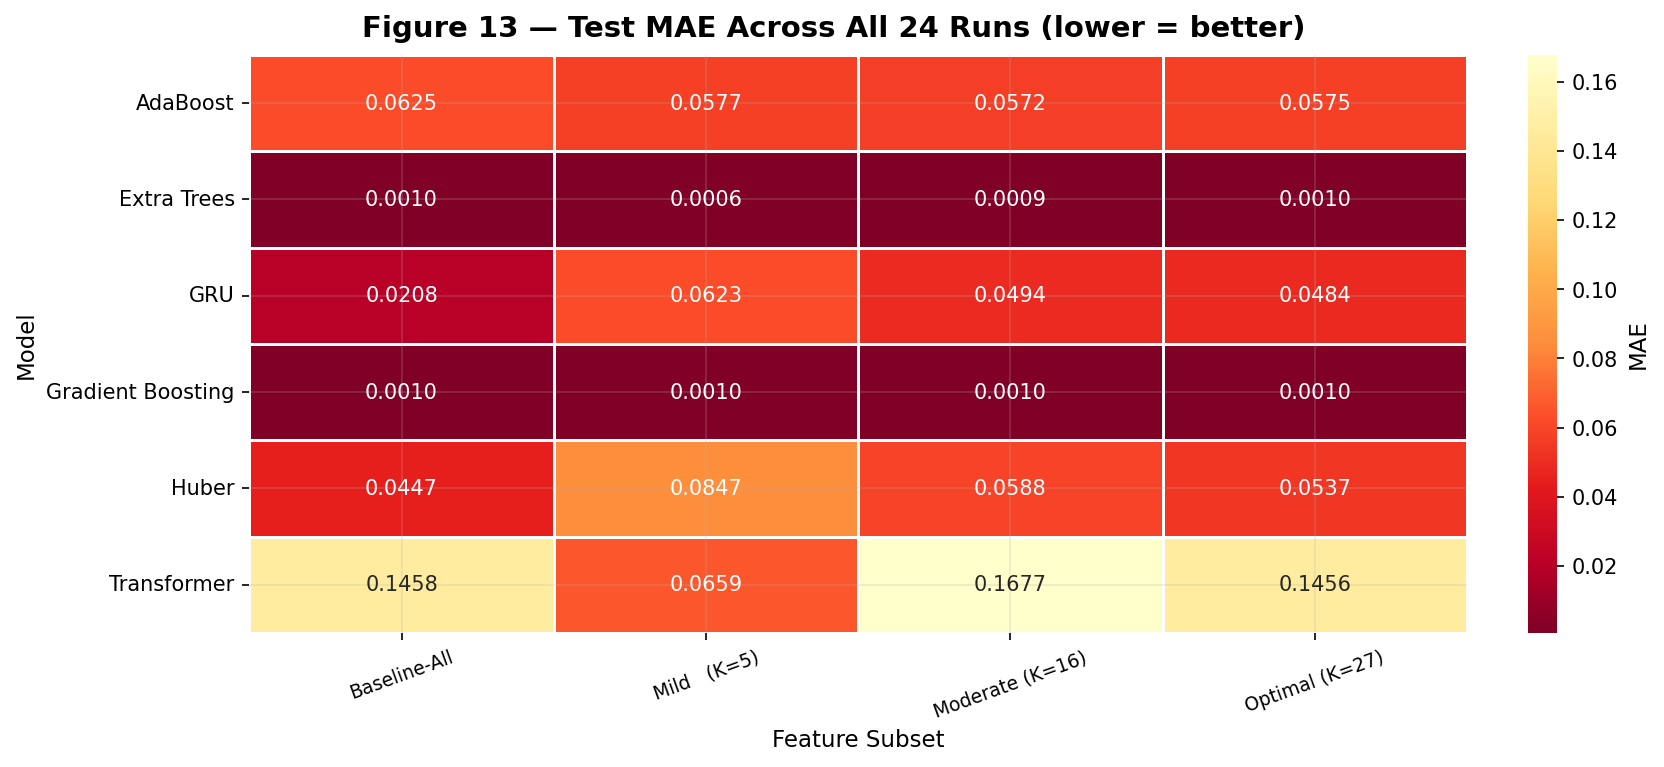

In [34]:
fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("Figure 13 — Test MAE Across All 24 Runs (lower = better)", fontweight="bold")

pivot_mae = results_df.pivot_table(index="Model", columns="FeatureSet", values="MAE")
pivot_mae = pivot_mae[[c for c in col_order if c in pivot_mae.columns]]
pivot_mae.columns = [c.strip() for c in pivot_mae.columns]
sns.heatmap(pivot_mae, annot=True, fmt=".4f", cmap="YlOrRd_r", linewidths=0.5,
            cbar_kws={"label":"MAE"}, annot_kws={"size":10}, ax=ax)
ax.set(xlabel="Feature Subset", ylabel="Model")
ax.tick_params(axis="x", rotation=20, labelsize=9)

savefig("13_mae_heatmap")

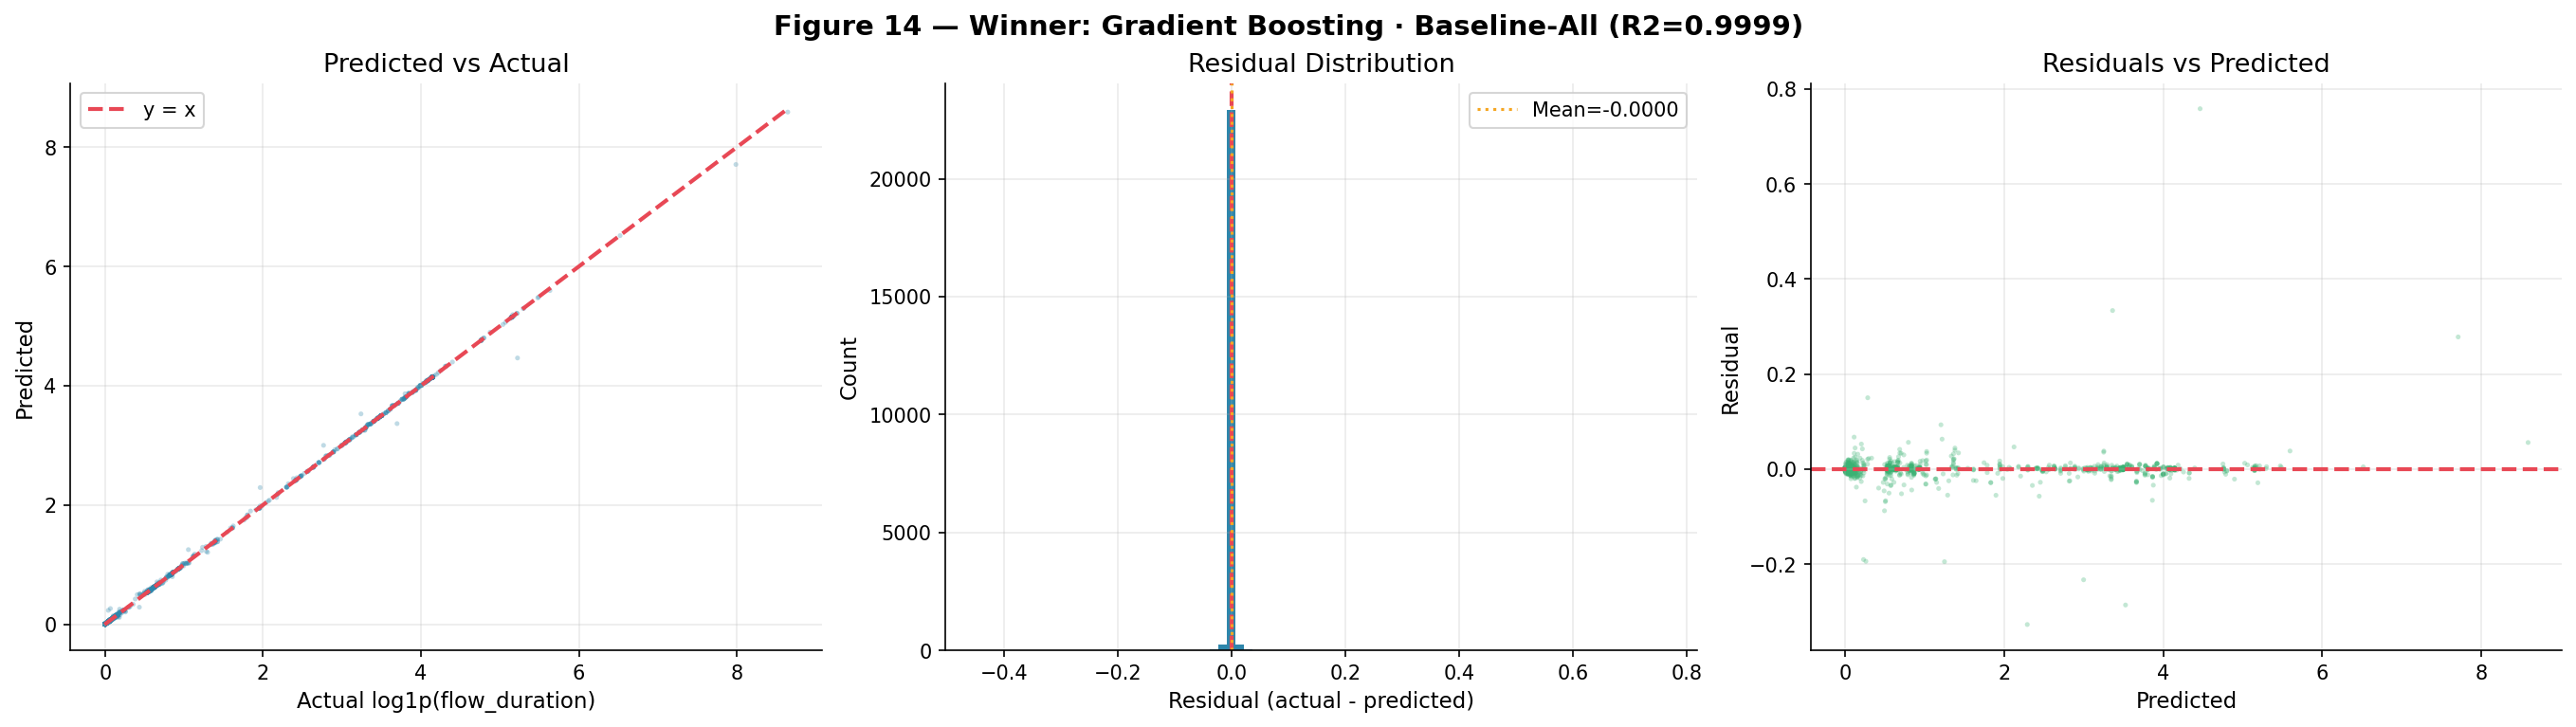

In [35]:
winner_idx = results_df["R2"].idxmax()
winner     = results_df.iloc[winner_idx]
w_key      = f"{winner['Model']}|{winner['FeatureSet']}"
y_true, y_pred_w = predictions[w_key]
residuals  = y_true - y_pred_w

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"Figure 14 — Winner: {winner['Model'].strip()} · {winner['FeatureSet'].strip()} "
    f"(R2={winner['R2']:.4f})",
    fontweight="bold"
)

# Scatter: predicted vs actual
sample = np.random.choice(len(y_true), size=min(10000, len(y_true)), replace=False)
axes[0].scatter(y_true[sample], y_pred_w[sample], alpha=0.3, s=6,
                color=PALETTE[0], edgecolors="none")
lim = [min(y_true.min(), y_pred_w.min()), max(y_true.max(), y_pred_w.max())]
axes[0].plot(lim, lim, "--", color=PALETTE[1], linewidth=2, label="y = x")
axes[0].set(xlabel="Actual log1p(flow_duration)",
            ylabel="Predicted", title="Predicted vs Actual")
axes[0].legend()

# Residual histogram
axes[1].hist(residuals, bins=80, color=PALETTE[0], edgecolor="none")
axes[1].axvline(0, color=PALETTE[1], linestyle="--", linewidth=2)
axes[1].axvline(residuals.mean(), color=PALETTE[3], linestyle=":", linewidth=1.5,
                label=f"Mean={residuals.mean():.4f}")
axes[1].set(xlabel="Residual (actual - predicted)",
            ylabel="Count", title="Residual Distribution")
axes[1].legend()

# Residuals vs predicted
axes[2].scatter(y_pred_w[sample], residuals[sample], alpha=0.3, s=6,
                color=PALETTE[2], edgecolors="none")
axes[2].axhline(0, color=PALETTE[1], linestyle="--", linewidth=2)
axes[2].set(xlabel="Predicted", ylabel="Residual",
            title="Residuals vs Predicted")

savefig("14_winner_analysis")

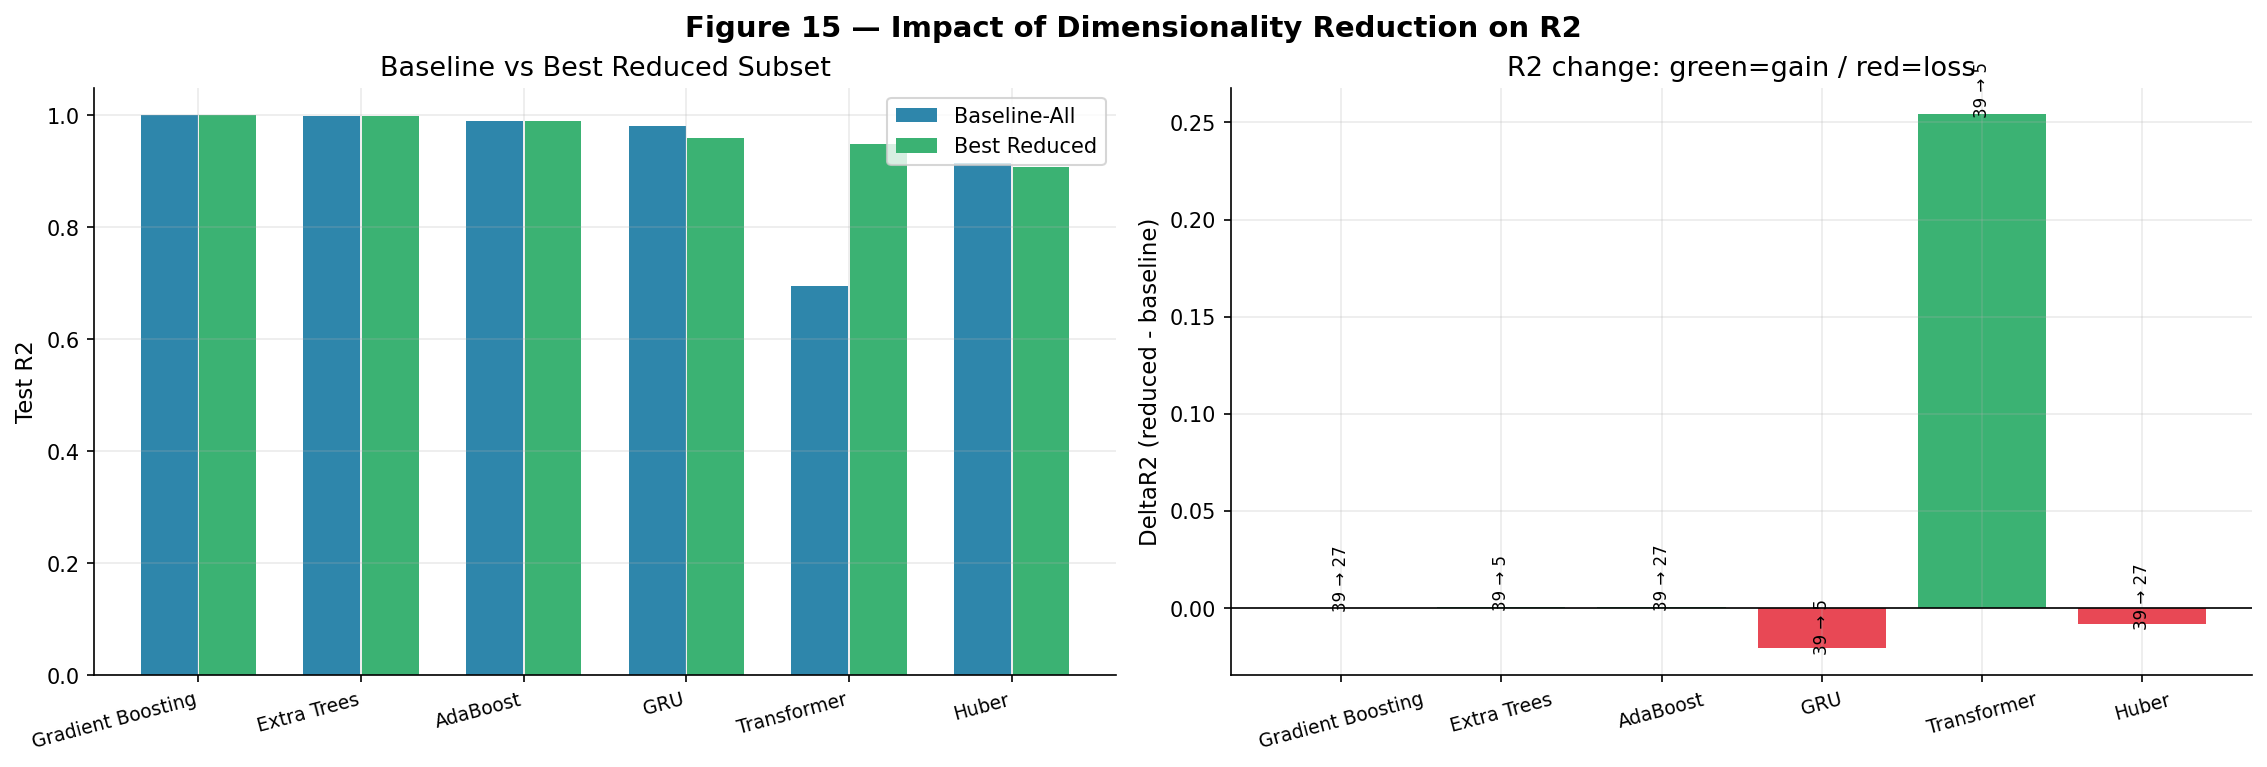

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Figure 15 — Impact of Dimensionality Reduction on R2",
             fontweight="bold")

# Left: Delta R2 per model (grouped bars, Baseline vs each reduced set)
model_names2 = summary_df.Model.tolist()
x = np.arange(len(model_names2))
axes[0].bar(x, summary_df["Baseline R2"],    width=0.35, label="Baseline-All",
            color=PALETTE[0], edgecolor="none")
axes[0].bar(x + 0.36, summary_df["Best Reduced R2"], width=0.35, label="Best Reduced",
            color=PALETTE[2], edgecolor="none")
axes[0].set_xticks(x + 0.18)
axes[0].set_xticklabels(model_names2, rotation=15, ha="right", fontsize=9)
axes[0].set(ylabel="Test R2", title="Baseline vs Best Reduced Subset")
axes[0].legend()

# Right: DeltaR2 scatter (how much was lost / gained by reducing)
delta_colors = [PALETTE[2] if v >= 0 else PALETTE[1]
                for v in summary_df["DeltaR2"]]
axes[1].bar(model_names2, summary_df["DeltaR2"], color=delta_colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(ylabel="DeltaR2 (reduced - baseline)",
            title="R2 change: green=gain / red=loss")
axes[1].tick_params(axis="x", rotation=15, labelsize=9)
for i, (v, f) in enumerate(zip(summary_df["DeltaR2"], summary_df["Features"])):
    axes[1].text(i, v + (0.0003 if v >= 0 else -0.0008),
                 f, ha="center", fontsize=8, rotation=90)

savefig("15_reduction_impact")

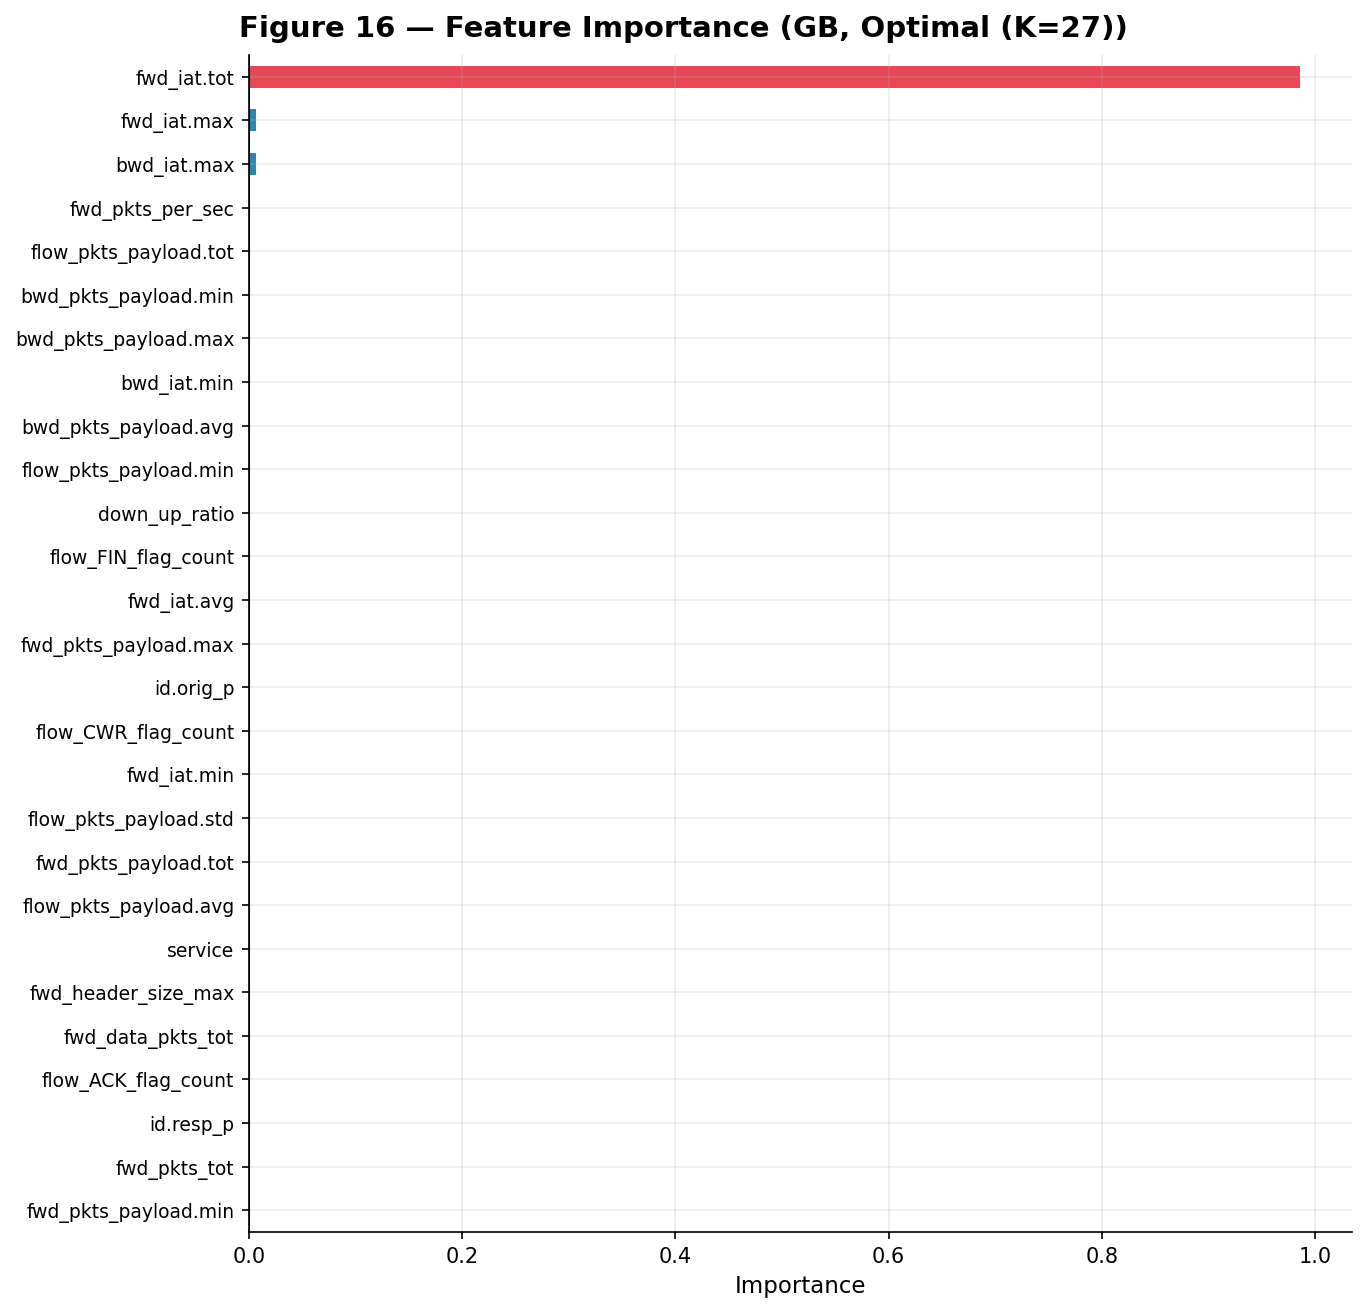

In [37]:
# GB importance on the Optimal subset
opt_fs_name = [k for k in splits if "Optimal" in k][0]
Xtr_o, _, ytr_o, _ = splits[opt_fs_name]
gb_final = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                     learning_rate=0.1, random_state=SEED)
gb_final.fit(Xtr_o, ytr_o)
opt_feats = feature_subsets[opt_fs_name]
imp = pd.Series(gb_final.feature_importances_, index=opt_feats).sort_values()

fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(imp))))
fig.suptitle(f"Figure 16 — Feature Importance (GB, {opt_fs_name.strip()})",
             fontweight="bold")
colors_imp = [PALETTE[1] if v == imp.max() else PALETTE[0] for v in imp.values]
imp.plot(kind="barh", ax=ax, color=colors_imp, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.5)
ax.set(xlabel="Importance", ylabel="")
ax.tick_params(axis="y", labelsize=9)

savefig("16_feature_importance")

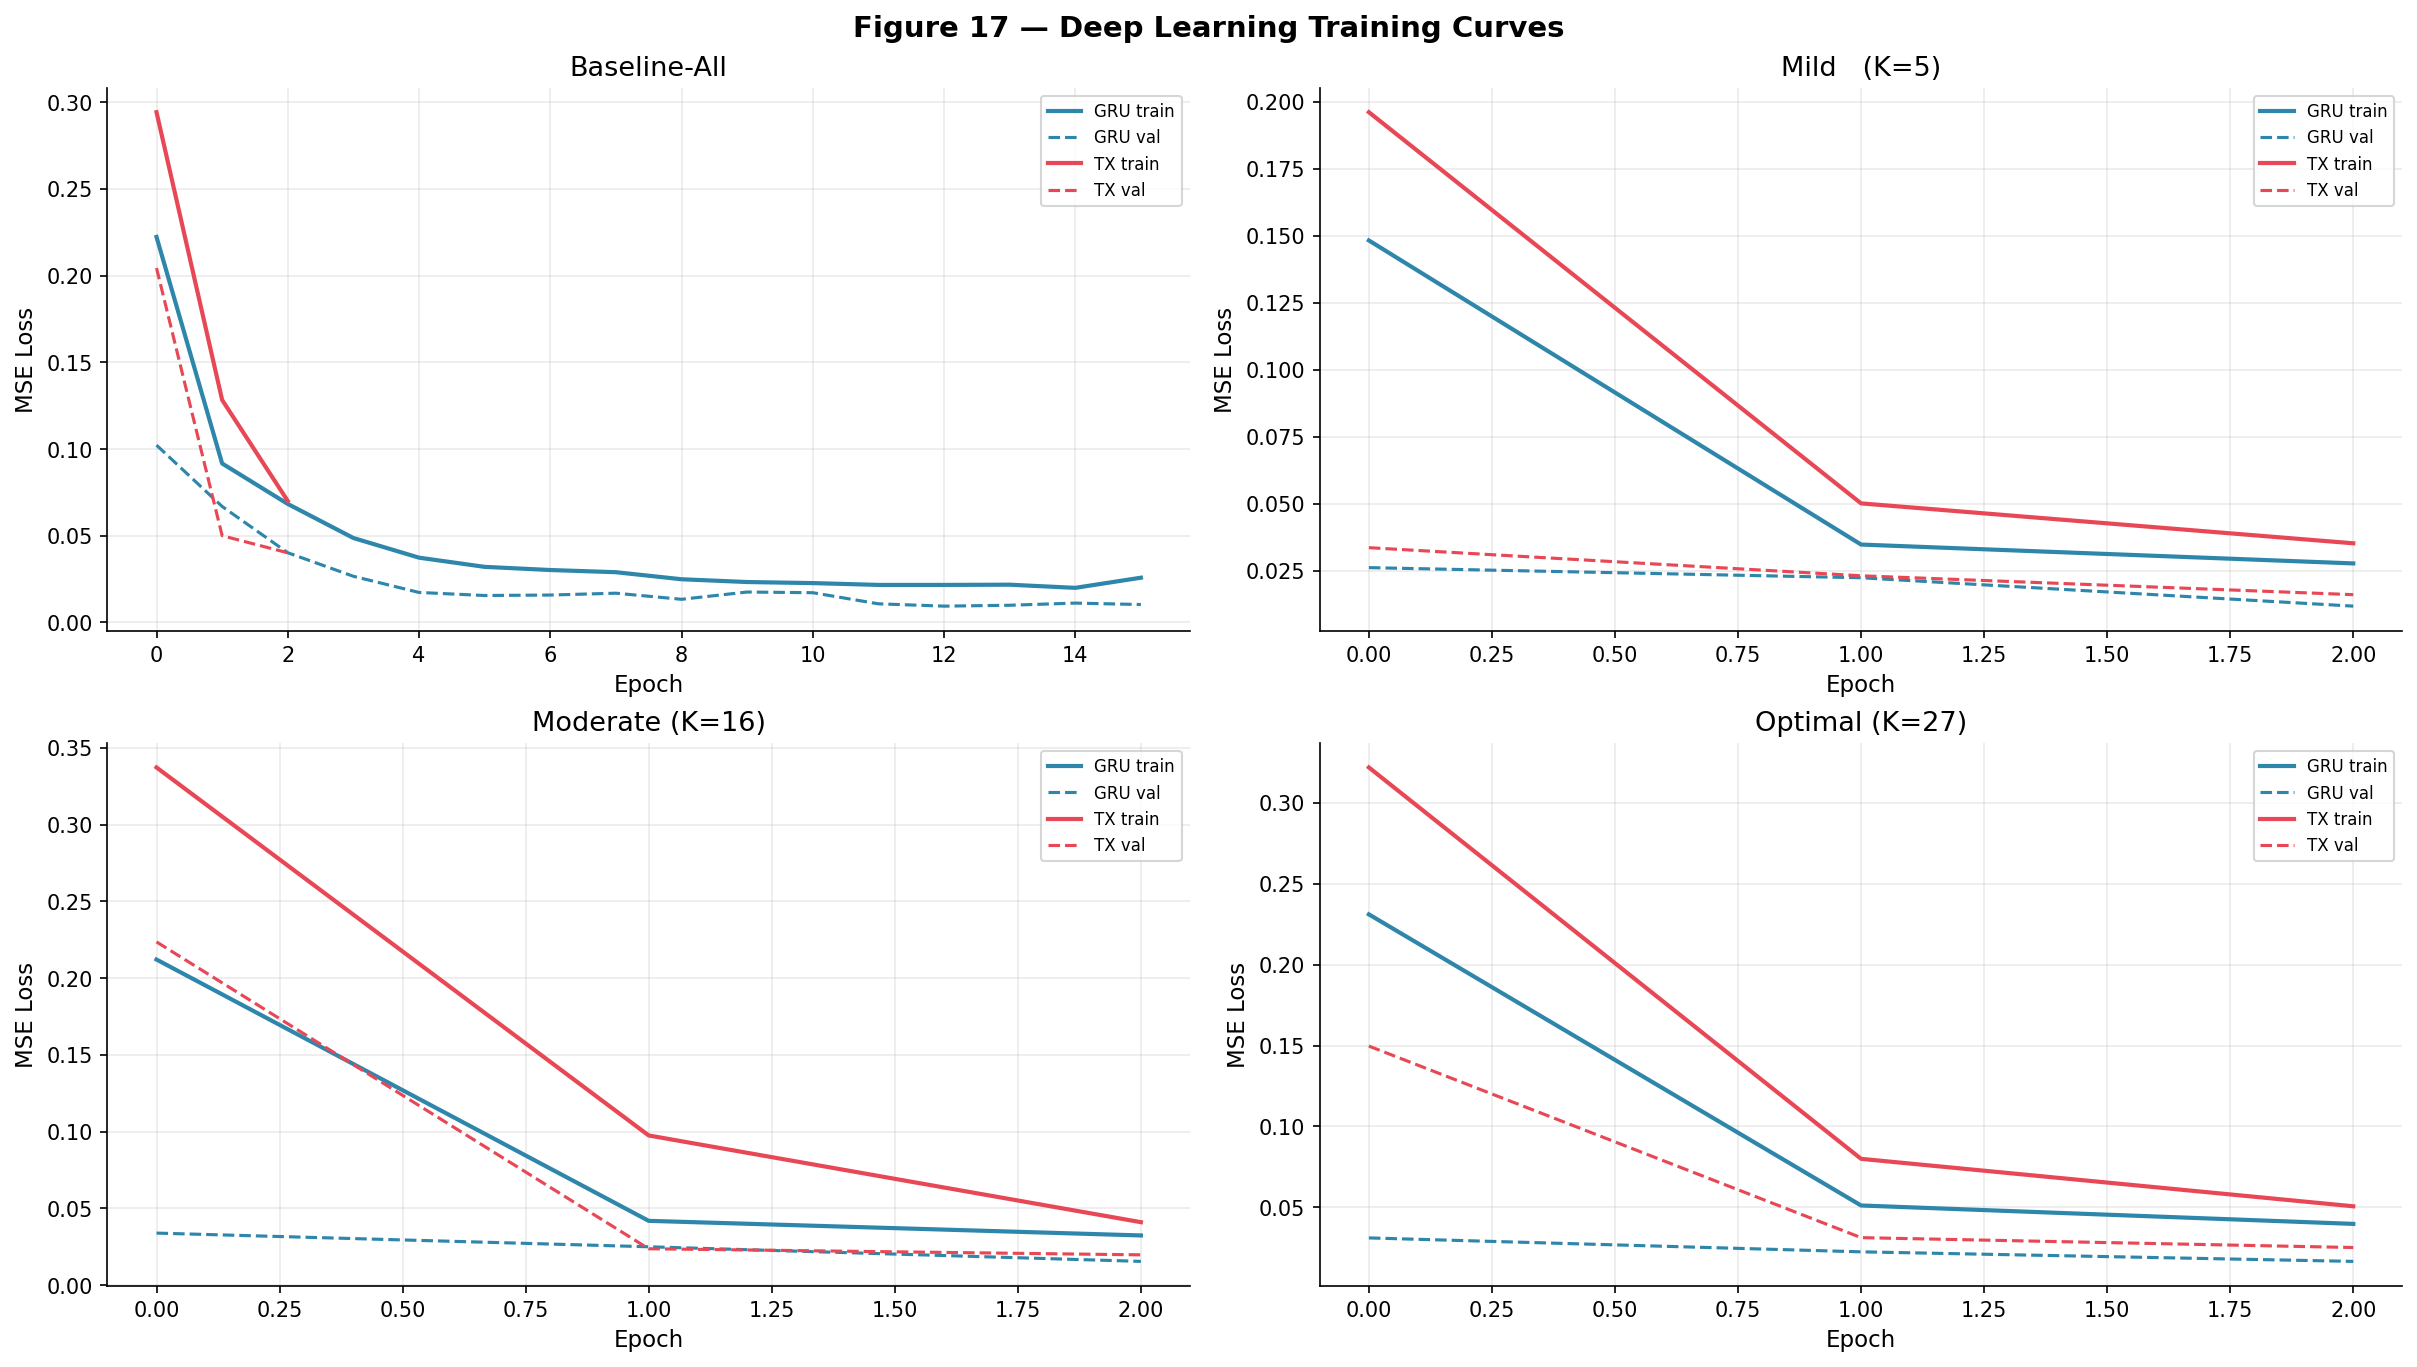

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("Figure 17 — Deep Learning Training Curves", fontweight="bold")

fs_list = list(gru_hist.keys())
for j, fs_name in enumerate(fs_list):
    row = j // 2; col_idx = j % 2
    ax = axes[row, col_idx] if len(fs_list) > 2 else axes[row]

    h_gru = gru_hist[fs_name]
    h_tx  = tx_hist[fs_name]
    ax.plot(h_gru["loss"],     color=PALETTE[0], linewidth=2.0, label="GRU train")
    ax.plot(h_gru["val_loss"], color=PALETTE[0], linewidth=1.5, linestyle="--", label="GRU val")
    ax.plot(h_tx["loss"],      color=PALETTE[1], linewidth=2.0, label="TX train")
    ax.plot(h_tx["val_loss"],  color=PALETTE[1], linewidth=1.5, linestyle="--", label="TX val")
    ax.set(title=fs_name.strip(), xlabel="Epoch", ylabel="MSE Loss")
    ax.legend(fontsize=8)

# hide extra axes if < 4 subsets
for j in range(len(fs_list), 4):
    axes.flat[j].set_visible(False)

savefig("17_training_curves")

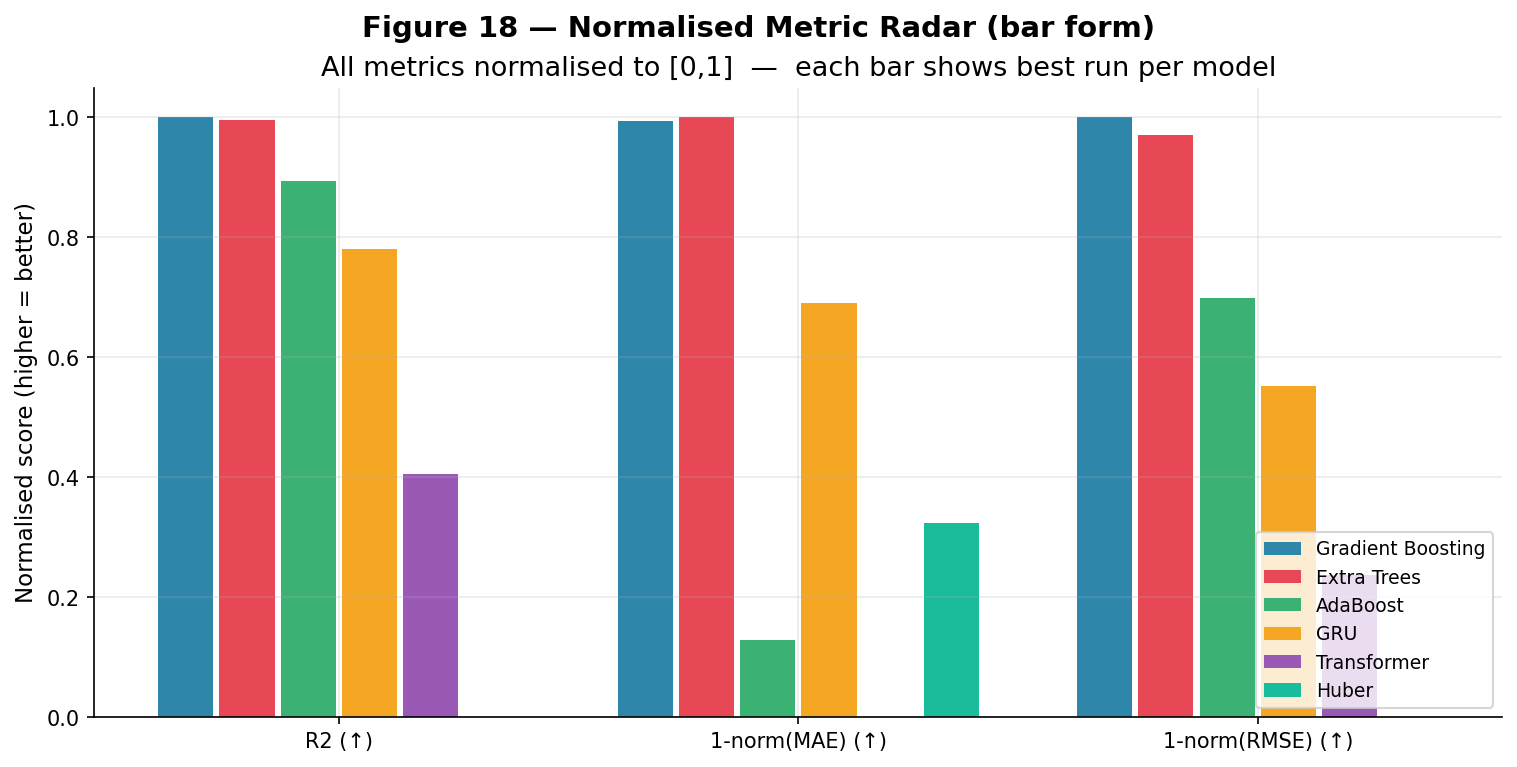

In [39]:
from matplotlib.patches import FancyArrowPatch

# Build a simple multi-metric comparison for each model (best run only)
metrics_compare = ["R2", "MAE", "RMSE"]
models_best = best_per.set_index("Model")[metrics_compare]

# Normalise to [0,1]: for error metrics, invert (1 - normalised)
models_norm = models_best.copy()
for col in ["MAE", "RMSE"]:
    mn, mx = models_norm[col].min(), models_norm[col].max()
    models_norm[col] = 1 - (models_norm[col] - mn) / (mx - mn + 1e-12)
# R2 already [0,1]
mn, mx = models_norm["R2"].min(), models_norm["R2"].max()
if mx > mn:
    models_norm["R2"] = (models_norm["R2"] - mn) / (mx - mn)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Figure 18 — Normalised Metric Radar (bar form)", fontweight="bold")

x = np.arange(len(metrics_compare))
width = 0.8 / len(models_norm)
for i, (model, row) in enumerate(models_norm.iterrows()):
    ax.bar(x + i * width, row.values, width=width * 0.9,
           label=model, color=PALETTE[i % len(PALETTE)])
ax.set_xticks(x + width * (len(models_norm) / 2 - 0.5))
ax.set_xticklabels(["R2 (↑)", "1-norm(MAE) (↑)", "1-norm(RMSE) (↑)"])
ax.set(ylabel="Normalised score (higher = better)",
       title="All metrics normalised to [0,1]  —  each bar shows best run per model")
ax.legend(loc="lower right", fontsize=9)

savefig("18_normalised_metrics")

## 12 · Save Models, Artifacts, and Download Everything

In [41]:
# ── Save classical ML models (best subset per algorithm) ─────────
print("Saving models …")
model_map = {
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                   learning_rate=0.1, random_state=SEED),
    "Extra Trees"      : ExtraTreesRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
    "AdaBoost"         : AdaBoostRegressor(n_estimators=150, learning_rate=0.1, random_state=SEED),
    "Huber"            : HuberRegressor(max_iter=500, alpha=0.001),
}
for mname, mobj in model_map.items():
    row   = results_df[results_df.Model == mname].sort_values("R2", ascending=False).iloc[0]
    fs    = row["FeatureSet"]
    Xtr_, _, ytr_, _ = splits[fs]
    mobj.fit(Xtr_, ytr_)
    fname = "saved_models/" + mname.lower().replace(" ", "_") + ".joblib"
    joblib.dump(mobj, fname)
    print(f"  ✔ {fname:50s}  (subset: {fs.strip()})")

# ── Save DL models (best subset per architecture) ────────────────
for arch_name, hist_dict, model_dict in [("gru", gru_hist, gru_models),
                                         ("transformer", tx_hist, tx_models)]:

    # 1. Resolve the model name cleanly before doing pandas lookups
    target_name = "GRU" if arch_name == "gru" else "Transformer"

    # 2. Use the resolved name in the pandas filter
    best_fs = max(
        hist_dict.keys(),
        key=lambda k: results_df[
            (results_df.Model == target_name) &
            (results_df.FeatureSet == k)
        ]["R2"].values[0]
        if not results_df[
            (results_df.Model == target_name) &
            (results_df.FeatureSet == k)
        ].empty else 0
    )

    fname = f"saved_models/{arch_name}_regressor.keras"
    model_dict[best_fs].save(fname)
    print(f"  ✔ {fname}")

# ── Save supporting artifacts ────────────────────────────────────
joblib.dump(scaler,               "saved_models/scaler.joblib")
joblib.dump(le_proto,             "saved_models/le_proto.joblib")
joblib.dump(le_service,           "saved_models/le_service.joblib")
joblib.dump(feature_subsets,      "saved_models/feature_subsets.joblib")
joblib.dump(results_df,           "saved_models/results_df.joblib")
joblib.dump({
    "K_MILD": K_MILD, "K_MOD": K_MOD, "K_OPT": K_OPT,
    "N_PRUNED": N_PRUNED, "best_method": best_method_name,
    "pruned_features": X_pruned.columns.tolist(),
    "dropped_variance": near_const, "dropped_corr": sorted(to_drop),
    "baseline_r2": float(results_df[results_df.FeatureSet=="Baseline-All"]["R2"].max()),
}, "saved_models/pipeline_config.joblib")
print("  ✔ Supporting artifacts saved")

print(f"\nSaved models dir:")
for f in sorted(os.listdir("saved_models")): print(f"  {f}")

Saving models …
  ✔ saved_models/gradient_boosting.joblib               (subset: Baseline-All)
  ✔ saved_models/extra_trees.joblib                     (subset: Mild   (K=5))
  ✔ saved_models/adaboost.joblib                        (subset: Optimal (K=27))
  ✔ saved_models/huber.joblib                           (subset: Baseline-All)
  ✔ saved_models/gru_regressor.keras
  ✔ saved_models/transformer_regressor.keras
  ✔ Supporting artifacts saved

Saved models dir:
  adaboost.joblib
  extra_trees.joblib
  feature_subsets.joblib
  gradient_boosting.joblib
  gru_regressor.keras
  huber.joblib
  le_proto.joblib
  le_service.joblib
  pipeline_config.joblib
  results_df.joblib
  scaler.joblib
  transformer_regressor.keras


In [42]:
# ── Create downloadable ZIP ───────────────────────────────────────
ZIP_NAME = "RT_IoT2022_results_package.zip"
with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as zf:
    for folder in ["figures", "saved_models"]:
        for fname in os.listdir(folder):
            zf.write(os.path.join(folder, fname),
                     arcname=os.path.join(folder, fname))

print(f"✅  ZIP created: {ZIP_NAME}  "
      f"({os.path.getsize(ZIP_NAME)/1e6:.1f} MB)")
print(f"   → {len([n for n in zf.namelist() if n.startswith('figures')])} figures")
print(f"   → {len([n for n in zf.namelist() if n.startswith('saved_models')])} model files")

# ── Trigger Colab download ────────────────────────────────────────
try:
    from google.colab import files
    files.download(ZIP_NAME)
    print("\nDownload started in your browser.")
except ImportError:
    print(f"\nNot in Colab — find your ZIP at: {os.path.abspath(ZIP_NAME)}")

✅  ZIP created: RT_IoT2022_results_package.zip  (103.5 MB)
   → 18 figures
   → 12 model files


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started in your browser.


## 13 · Study Summary

| Stage | Detail | Output |
|-------|--------|--------|
| Dataset | 117,915 deduplicated flows, 50 features, 1 continuous target | Full corpus used |
| Preprocessing | Dedup → label-encode → log1p target → StandardScaler | 50 features |
| Variance filter | Drop near-constant columns | 50 → 49 |
| Correlation pruning | Drop redundant (`|r|>0.95`), keep higher-corr member | 49 → 39 |
| Method comparison | Pearson vs MI vs GB-importance — best method identified | Best ranker ✓ |
| K-sweep | Validate R² vs K curve, locate elbow | K_MILD, K_MOD, K_OPT |
| Final subsets | Baseline-All (39) + 3 progressive reductions | 4 subsets |
| Training | 4 ML + 2 DL, 4 subsets each | **24 runs** |
| Download | Figures (18 PNGs, 200 dpi) + 9 model files in ZIP | ✓ |

All figures are saved in `figures/` and included in the ZIP download.